<a href="https://colab.research.google.com/github/khalid-saqr/xPeerd_Evaluation/blob/main/TRACE_R_xPeerd_Evaluation_2026_v3_0_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TRACE-R: Transparent evaluation of xPeerd versus human peer review

This standalone Colab notebook evaluates only manuscripts with **exactly two non-empty human review reports and exactly two non-empty xPeerd reviewer reports**. Every other record is excluded before analysis through mutually exclusive, record-level criteria.

The automated TRACE-R profile remains locked to verifiable observables and explicitly labelled proxies:

- **T — Targeting:** explicit manuscript targets and retrievable manuscript passages.
- **R — Reasoning:** explicit rationale or consequence language.
- **A — Attested alignment:** lexical/TF–IDF manuscript alignment; **not scientific accuracy**.
- **C — Coverage:** breadth across a prespecified review-topic taxonomy.
- **E — Executability:** explicit revision actions.
- **R — Relevance:** scientific/methodological rather than purely stylistic or administrative content.

The enriched analysis separates **association** from **agreement**. It reports deterministic coefficients and diagnostics (Pearson, Spearman, Kendall, distance correlation, Lin concordance, partial rank correlation, MAE, RMSE, Bland–Altman bias/limits, category Jaccard/phi, recommendation kappa) alongside probabilistic uncertainty and testing (bootstrap confidence intervals, permutation tests, paired Wilcoxon tests, exact McNemar tests, and false-discovery-rate correction).

No automated result is interpreted as true scientific correctness, true novelty, complete flaw recall, severity calibration, epistemic harm, or proof that one review source is superior. Those claims require blinded expert adjudication or controlled ground truth.


In [1]:
# CELL 1 — Environment, Drive mount, paths, constants, and reproducibility
import os, sys, re, json, gzip, math, random, hashlib, platform, warnings, zipfile, shutil
from pathlib import Path
from datetime import datetime, timezone
from collections import Counter, defaultdict

IN_COLAB = 'google.colab' in sys.modules or Path('/content').exists() and Path('/content/drive').exists()
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    drive = None

if IN_COLAB and drive is not None:
    drive.mount('/content/drive', force_remount=False)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.optimize import linear_sum_assignment
from scipy.stats import wilcoxon, pearsonr, spearmanr, kendalltau, binomtest, rankdata
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
from sklearn.metrics import cohen_kappa_score

warnings.filterwarnings('ignore', category=FutureWarning)
SEED = 20260723
random.seed(SEED)
np.random.seed(SEED)

DRIVE_STUDY_ROOT = Path('/content/drive/MyDrive/xpeerd_benchmarks/xPeerd_Benchmark_Study_2026')
DRIVE_INPUT_DIR = DRIVE_STUDY_ROOT / 'processed' / 'final_dataset'
DRIVE_TRACE_ROOT = DRIVE_STUDY_ROOT / 'TRACE-R'

# Local-only variables permit full execution testing outside Colab; they are ignored in Colab.
TEST_ZIP = os.environ.get('TRACE_R_TEST_ZIP', '').strip()
TEST_OUTPUT = os.environ.get('TRACE_R_TEST_OUTPUT', '').strip()

if TEST_ZIP:
    ZIP_PATH = Path(TEST_ZIP).expanduser().resolve()
    TRACE_ROOT = Path(TEST_OUTPUT or '/tmp/TRACE-R-test').expanduser().resolve()
else:
    if not DRIVE_INPUT_DIR.exists():
        raise FileNotFoundError(f'Drive input directory not found: {DRIVE_INPUT_DIR}')
    candidates = sorted(DRIVE_INPUT_DIR.glob('*.zip'))
    preferred = [p for p in candidates if p.name.lower().startswith('xpeerd_benchmark_study_2026')]
    if not candidates:
        raise FileNotFoundError(f'No ZIP package found in {DRIVE_INPUT_DIR}')
    ZIP_PATH = max(preferred or candidates, key=lambda p: p.stat().st_size)
    TRACE_ROOT = DRIVE_TRACE_ROOT

if not ZIP_PATH.exists():
    raise FileNotFoundError(f'Dataset package not found: {ZIP_PATH}')

# Clear only files/directories generated by this notebook, never the parent study directory.
TRACE_ROOT.mkdir(parents=True, exist_ok=True)
for name in ['data', 'tables', 'figures', 'logs']:
    generated_dir = TRACE_ROOT / name
    if generated_dir.exists():
        shutil.rmtree(generated_dir)
for filename in ['config.json','cohort_summary.json','output_manifest.csv','TRACE_R_COMPLETION_REPORT.json']:
    generated_file = TRACE_ROOT / filename
    if generated_file.exists():
        generated_file.unlink()
DIRS = {name: TRACE_ROOT / name for name in ['data', 'tables', 'figures', 'logs']}
for p in DIRS.values():
    p.mkdir(parents=True, exist_ok=True)

CONFIG = {
    'seed': SEED,
    'required_human_reviewers': 2,
    'required_xPeerd_reviewers': 2,
    'minimum_unit_words': 5,
    'manuscript_chunk_words': 160,
    'manuscript_chunk_overlap_words': 40,
    'default_match_threshold': 0.35,
    'sensitivity_thresholds': [0.25, 0.30, 0.35, 0.40, 0.45, 0.50],
    'bootstrap_replicates': 2000,
    'permutation_replicates': 1999,
    'created_utc': datetime.now(timezone.utc).isoformat(),
    'python': platform.python_version(),
}

def sha256_file(path, block=1024*1024):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(block), b''):
            h.update(chunk)
    return h.hexdigest()

CONFIG['input_zip'] = str(ZIP_PATH)
CONFIG['input_sha256'] = sha256_file(ZIP_PATH)
(TRACE_ROOT / 'config.json').write_text(json.dumps(CONFIG, indent=2), encoding='utf-8')
print(f'Input package: {ZIP_PATH}')
print(f'TRACE-R output root: {TRACE_ROOT}')
print(f'Input SHA-256: {CONFIG["input_sha256"]}')

Mounted at /content/drive
Input package: /content/drive/MyDrive/xpeerd_benchmarks/xPeerd_Benchmark_Study_2026/processed/final_dataset/xpeerd_benchmark_study_2026_v1.0.0.zip
TRACE-R output root: /content/drive/MyDrive/xpeerd_benchmarks/xPeerd_Benchmark_Study_2026/TRACE-R
Input SHA-256: 0ab7cb88d2b2db687b586ad303e017a9db0a8104e10f1b8e18c30b8f6a75129c


In [2]:
# CELL 2 — Load, validate, and establish transparent mutually exclusive exclusions
with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    members = [n for n in zf.namelist() if n.endswith('.jsonl.gz')]
    if len(members) != 1:
        raise RuntimeError(f'Expected exactly one .jsonl.gz member; found {members}')
    JSONL_MEMBER = members[0]
    with zf.open(JSONL_MEMBER, 'r') as raw, gzip.GzipFile(fileobj=raw, mode='rb') as gz:
        records = [json.loads(line) for line in gz if line.strip()]

REQUIRED_TOP = {'benchmark_id', 'document_id', 'manuscript', 'human_reviews', 'xpeer_simulation'}
if not records:
    raise RuntimeError('Dataset contains zero records.')
for i, record in enumerate(records):
    missing = REQUIRED_TOP - set(record)
    if missing:
        raise RuntimeError(f'Record {i} missing top-level fields: {sorted(missing)}')

def nonempty_text(value):
    return isinstance(value, str) and bool(value.strip())

audit = []
for i, r in enumerate(records):
    humans = r.get('human_reviews') or []
    x = r.get('xpeer_simulation') or {}
    n_human = sum(isinstance(h, dict) and nonempty_text(h.get('review_text')) for h in humans)
    n_xpeer = sum(nonempty_text(x.get(k)) for k in ('Reviewer1', 'Reviewer2'))
    manuscript_ok = nonempty_text((r.get('manuscript') or {}).get('manuscript_text'))

    if n_human != 2:
        reason = f'exclude_human_review_count_{n_human}'
        include = False
    elif not manuscript_ok:
        reason = 'exclude_missing_manuscript_text'
        include = False
    elif n_xpeer != 2:
        reason = f'exclude_xPeerd_reviewer_count_{n_xpeer}'
        include = False
    else:
        reason = 'include_exactly_two_human_and_two_xPeerd'
        include = True

    audit.append({
        'record_index': i,
        'benchmark_id': r.get('benchmark_id'),
        'document_id': r.get('document_id'),
        'nonempty_human_review_count': n_human,
        'nonempty_xPeerd_reviewer_count': n_xpeer,
        'manuscript_text_present': manuscript_ok,
        'included': include,
        'criterion': reason,
    })

audit_df = pd.DataFrame(audit)
if audit_df['benchmark_id'].duplicated().any():
    dupes = audit_df.loc[audit_df['benchmark_id'].duplicated(), 'benchmark_id'].tolist()[:10]
    raise RuntimeError(f'Duplicate benchmark_id values detected: {dupes}')

exclusion_summary = (audit_df.groupby(['included', 'criterion'], dropna=False)
                     .size().rename('n').reset_index().sort_values(['included', 'criterion']))
included_indices = audit_df.loc[audit_df['included'], 'record_index'].astype(int).tolist()
included_records = [records[i] for i in included_indices]

# Pinned-package invariants. A changed package fails loudly instead of silently changing the cohort.
EXPECTED = {'all_records': 1108, 'exactly_two_human': 802, 'strict_two_vs_two': 271}
observed = {
    'all_records': len(records),
    'exactly_two_human': int((audit_df['nonempty_human_review_count'] == 2).sum()),
    'strict_two_vs_two': len(included_records),
}
for key, expected in EXPECTED.items():
    if observed[key] != expected:
        raise RuntimeError(f'Pinned dataset invariant failed for {key}: {observed[key]} != {expected}')
if exclusion_summary['n'].sum() != len(records):
    raise RuntimeError('Exclusion counts do not reconcile to total records.')

summary = {
    'package': ZIP_PATH.name,
    'jsonl_member': JSONL_MEMBER,
    **observed,
    'excluded_total': len(records) - len(included_records),
    'criteria_are_mutually_exclusive': True,
}

audit_df.to_csv(DIRS['tables'] / 'cohort_record_audit.csv', index=False)
exclusion_summary.to_csv(DIRS['tables'] / 'exclusion_summary.csv', index=False)
(TRACE_ROOT / 'cohort_summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')

print(json.dumps(summary, indent=2))
print('\nMutually exclusive inclusion/exclusion criteria:')
print(exclusion_summary.to_string(index=False))

{
  "package": "xpeerd_benchmark_study_2026_v1.0.0.zip",
  "jsonl_member": "data/evaluation_cases.jsonl.gz",
  "all_records": 1108,
  "exactly_two_human": 802,
  "strict_two_vs_two": 271,
  "excluded_total": 837,
  "criteria_are_mutually_exclusive": true
}

Mutually exclusive inclusion/exclusion criteria:
 included                                criterion   n
    False             exclude_human_review_count_3 265
    False             exclude_human_review_count_4  33
    False             exclude_human_review_count_5   8
    False          exclude_xPeerd_reviewer_count_0 421
    False          exclude_xPeerd_reviewer_count_1 110
     True include_exactly_two_human_and_two_xPeerd 271


In [3]:
# CELL 3 — Construct four-report paired dataset and clean only declared boilerplate
BOILERPLATE_PATTERNS = [
    re.compile(r'\n?I never store any files beyond your sessions\..*?(?=\n\n|$)', re.I | re.S),
    re.compile(r'\n?I[’\']?m ready to assist with.*$', re.I | re.S),
    re.compile(r'\n?If you upload a revised version.*$', re.I | re.S),
]

def normalize_text(text):
    text = str(text or '').replace('\r\n', '\n').replace('\r', '\n')
    text = re.sub(r'[ \t]+', ' ', text)
    text = re.sub(r'\n{3,}', '\n\n', text).strip()
    return text

def clean_xPeerd_text(text):
    original = normalize_text(text)
    cleaned = original
    for pattern in BOILERPLATE_PATTERNS:
        cleaned = pattern.sub('', cleaned)
    cleaned = normalize_text(cleaned)
    return cleaned, len(original) - len(cleaned)

report_rows = []
boilerplate_removed_chars = 0
for r in included_records:
    bid = r['benchmark_id']
    manuscript = r['manuscript'] or {}
    human_reviews = r['human_reviews']
    x = r['xpeer_simulation'] or {}

    for idx, h in enumerate(human_reviews, start=1):
        text = normalize_text(h.get('review_text'))
        report_rows.append({
            'benchmark_id': bid, 'document_id': r.get('document_id'),
            'source': 'Human', 'reviewer_index': idx, 'report_id': f'{bid}|Human|{idx}',
            'report_text': text, 'human_recommendation': h.get('recommendation'),
            'manuscript_text': normalize_text(manuscript.get('manuscript_text')),
            'title': manuscript.get('title'), 'category': manuscript.get('category'),
            'boilerplate_removed_chars': 0,
        })

    for idx, field in enumerate(('Reviewer1', 'Reviewer2'), start=1):
        cleaned, removed = clean_xPeerd_text(x.get(field))
        boilerplate_removed_chars += removed
        report_rows.append({
            'benchmark_id': bid, 'document_id': r.get('document_id'),
            'source': 'xPeerd', 'reviewer_index': idx, 'report_id': f'{bid}|xPeerd|{idx}',
            'report_text': cleaned, 'human_recommendation': None,
            'manuscript_text': normalize_text(manuscript.get('manuscript_text')),
            'title': manuscript.get('title'), 'category': manuscript.get('category'),
            'boilerplate_removed_chars': removed,
        })

reports_df = pd.DataFrame(report_rows)
expected_reports = len(included_records) * 4
if len(reports_df) != expected_reports:
    raise RuntimeError(f'Expected {expected_reports} report rows; found {len(reports_df)}')
if reports_df.groupby(['benchmark_id', 'source']).size().ne(2).any():
    raise RuntimeError('Every included manuscript must have exactly two reports per source.')
if (~reports_df['report_text'].map(nonempty_text)).any():
    raise RuntimeError('Included report table contains an empty report.')

reports_df.drop(columns=['manuscript_text']).to_csv(DIRS['data'] / 'paired_reports.csv.gz', index=False, compression='gzip')
print({'included_manuscripts': len(included_records), 'report_rows': len(reports_df),
       'reports_per_source': reports_df['source'].value_counts().to_dict(),
       'xPeerd_boilerplate_characters_removed': boilerplate_removed_chars})

{'included_manuscripts': 271, 'report_rows': 1084, 'reports_per_source': {'Human': 542, 'xPeerd': 542}, 'xPeerd_boilerplate_characters_removed': 1655}


In [4]:
# CELL 4 — Deterministic concern-unit extraction and observable TRACE-R features
MIN_WORDS = CONFIG['minimum_unit_words']
WORD_RE = re.compile(r"\b[A-Za-z][A-Za-z0-9'’-]*\b")
HEADING_RE = re.compile(r'^[A-Z][A-Za-z0-9 /&()\-]{1,70}:?$')
BULLET_RE = re.compile(r'^\s*(?:[-*•]+|\d+[.)]|[A-Za-z][.)])\s*')

ACTION_RE = re.compile(r'\b(should|must|need(?:s|ed)? to|recommend|please|consider|clarify|add|include|report|explain|provide|revise|justify|discuss|correct|remove|define|specify|describe|address|ensure)\b', re.I)
RATIONALE_RE = re.compile(r'\b(because|since|therefore|thus|hence|so that|which (?:may|could|would)|leading to|due to|in order to|otherwise|this (?:limits|weakens|undermines|prevents))\b', re.I)
CONCERN_RE = re.compile(r'\b(unclear|insufficient|missing|lack(?:s|ing)?|limitation|concern|problem|issue|incorrect|inconsistent|unsupported|overstated|bias|confound|error|weakness|ambiguous|inadequate|not reported|not described|fails? to|cannot|could not)\b', re.I)
PRAISE_RE = re.compile(r'\b(strength|well written|clear|excellent|valuable|interesting|appropriate|adequate|meticulous|original)\b', re.I)
TARGET_RE = re.compile(r'\b(abstract|introduction|method(?:s|ology)?|results?|discussion|conclusion|figure|fig\.?|table|supplement|appendix|page|paragraph|section|equation|reference|citation|line|analysis|sample|cohort|dataset)\b', re.I)

CATEGORY_RULES = [
    ('statistics', re.compile(r'\b(statistic|regression|p[- ]?value|confidence interval|power|sample size|multiple comparison|variance|standard deviation|model fit|effect size|significan)\w*', re.I)),
    ('study_design', re.compile(r'\b(randomi[sz]|control group|blinding|cohort|case.control|cross.sectional|prospective|retrospective|selection bias|confound|inclusion criteria|exclusion criteria|study design)\b', re.I)),
    ('methods_reproducibility', re.compile(r'\b(method|protocol|procedure|assay|instrument|software|code|reproduc|replicat|data availability|materials|sampling|measurement)\w*', re.I)),
    ('data_results', re.compile(r'\b(data|result|figure|table|value|number|outcome|observation|image|plot|dataset)\b', re.I)),
    ('interpretation_claims', re.compile(r'\b(conclusion|interpret|claim|causal|mechanism|generaliz|overstat|support(?:ed)? by|inference|implication)\w*', re.I)),
    ('literature_context', re.compile(r'\b(reference|citation|literature|prior work|previous stud|novelty|context|bibliograph)\w*', re.I)),
    ('ethics_reporting', re.compile(r'\b(ethic|consent|approval|registration|conflict of interest|funding|reporting guideline|privacy|patient)\w*', re.I)),
    ('presentation_clarity', re.compile(r'\b(language|grammar|typo|format|formatting|wording|readability|clarity|structure|caption|legend|spelling|sentence|terminology)\w*', re.I)),
]
CATEGORY_ORDER = [x[0] for x in CATEGORY_RULES] + ['other_scientific']

def words(text):
    return WORD_RE.findall(text or '')

def classify_section(line):
    low = re.sub(r'[^a-z ]+', ' ', line.lower())
    if any(k in low for k in ['strength', 'positive aspect']): return 'strengths'
    if any(k in low for k in ['concern', 'weakness', 'major issue', 'minor issue', 'suggested improvement', 'key issue']): return 'concerns'
    if any(k in low for k in ['recommendation', 'overall judgment', 'decision', 'verdict']): return 'recommendation'
    if any(k in low for k in ['summary', 'overview', 'assessment']): return 'summary'
    return 'other'

def split_sentences(line):
    return [s.strip(' -•\t') for s in re.split(r'(?<=[.!?])\s+(?=[A-Z0-9“"(])', line) if s.strip()]

def concern_category(text):
    for name, pattern in CATEGORY_RULES:
        if pattern.search(text): return name
    return 'other_scientific'

def extract_units(report_row):
    units, section = [], 'other'
    for line_no, raw_line in enumerate(report_row.report_text.splitlines(), start=1):
        raw_line = raw_line.strip()
        if not raw_line: continue
        stripped = BULLET_RE.sub('', raw_line).strip()
        nwords = len(words(stripped))
        looks_heading = nwords <= 10 and (raw_line.endswith(':') or HEADING_RE.match(stripped))
        if looks_heading:
            section = classify_section(stripped)
            continue
        for sentence in split_sentences(stripped):
            wc = len(words(sentence))
            if wc < MIN_WORDS: continue
            action = bool(ACTION_RE.search(sentence))
            rationale = bool(RATIONALE_RE.search(sentence))
            concern = bool(CONCERN_RE.search(sentence)) or sentence.endswith('?')
            praise_only = bool(PRAISE_RE.search(sentence)) and not (action or concern)
            contextual_concern = section in {'concerns', 'recommendation'} and not praise_only
            if not (concern or action or contextual_concern):
                continue
            cat = concern_category(sentence)
            units.append({
                'benchmark_id': report_row.benchmark_id,
                'report_id': report_row.report_id,
                'source': report_row.source,
                'reviewer_index': report_row.reviewer_index,
                'line_no': line_no,
                'section_context': section,
                'unit_text': sentence,
                'word_count': wc,
                'target_explicit': int(bool(TARGET_RE.search(sentence))),
                'reasoning_explicit': int(rationale),
                'executable': int(action),
                'category': cat,
                'scientific_relevance': int(cat != 'presentation_clarity'),
                'question_form': int(sentence.endswith('?')),
            })
    return units

unit_rows = []
for row in reports_df.itertuples(index=False):
    unit_rows.extend(extract_units(row))
units_df = pd.DataFrame(unit_rows)
if units_df.empty:
    raise RuntimeError('Concern extraction produced zero units.')
if units_df['report_id'].nunique() < int(0.90 * len(reports_df)):
    raise RuntimeError('Concern extraction failed to produce units for at least 90% of reports.')

report_direct = (reports_df.assign(report_word_count=reports_df['report_text'].map(lambda x: len(words(x))))
                 [['benchmark_id','report_id','source','reviewer_index','report_word_count','boilerplate_removed_chars']])
concern_counts = units_df.groupby('report_id').size().rename('concern_count')
report_direct = report_direct.merge(concern_counts, on='report_id', how='left').fillna({'concern_count':0})
report_direct['concerns_per_1000_words'] = 1000 * report_direct['concern_count'] / report_direct['report_word_count'].clip(lower=1)

units_df.to_csv(DIRS['data'] / 'concern_units.csv.gz', index=False, compression='gzip')
report_direct.to_csv(DIRS['tables'] / 'report_direct_metrics.csv', index=False)
print({'concern_units': len(units_df), 'reports_with_units': units_df['report_id'].nunique(),
       'median_units_human': float(units_df.groupby('report_id').size().reindex(reports_df.loc[reports_df.source=='Human','report_id']).fillna(0).median()),
       'median_units_xPeerd': float(units_df.groupby('report_id').size().reindex(reports_df.loc[reports_df.source=='xPeerd','report_id']).fillna(0).median())})

{'concern_units': 15563, 'reports_with_units': 1023, 'median_units_human': 6.0, 'median_units_xPeerd': 18.0}


In [5]:
# CELL 5 — Manuscript chunking and attested alignment proxy (TF–IDF + token overlap)
STOPWORDS = set('a an and are as at be been being by for from had has have if in into is it its may might of on or our should than that the their there these they this those to was were which who will with would you your'.split())

def content_tokens(text):
    return {w.lower() for w in words(text) if len(w) > 2 and w.lower() not in STOPWORDS}

def chunk_words(text, size, overlap):
    toks = text.split()
    if not toks: return []
    step = max(1, size - overlap)
    return [' '.join(toks[i:i+size]) for i in range(0, len(toks), step) if toks[i:i+size]]

manuscripts = reports_df[['benchmark_id','manuscript_text']].drop_duplicates('benchmark_id').set_index('benchmark_id')['manuscript_text'].to_dict()
grounding_rows = []
for bid, sub in units_df.groupby('benchmark_id', sort=False):
    concerns = sub['unit_text'].tolist()
    chunks = chunk_words(manuscripts[bid], CONFIG['manuscript_chunk_words'], CONFIG['manuscript_chunk_overlap_words'])
    if not chunks:
        raise RuntimeError(f'No manuscript chunks for {bid}')
    corpus = chunks + concerns
    vectorizer = TfidfVectorizer(lowercase=True, stop_words='english', ngram_range=(1,2), sublinear_tf=True, max_features=30000)
    matrix = vectorizer.fit_transform(corpus)
    chunk_m = matrix[:len(chunks)]
    concern_m = matrix[len(chunks):]
    sim = linear_kernel(concern_m, chunk_m)
    best_idx = np.asarray(sim.argmax(axis=1)).ravel()
    best_score = np.asarray(sim.max(axis=1)).ravel()
    for local_i, (_, u) in enumerate(sub.iterrows()):
        c_tokens = content_tokens(u['unit_text'])
        p_tokens = content_tokens(chunks[int(best_idx[local_i])])
        overlap = len(c_tokens & p_tokens) / max(1, len(c_tokens))
        grounding_rows.append({
            'unit_index': int(u.name),
            'benchmark_id': bid,
            'source': u['source'],
            'best_chunk_index': int(best_idx[local_i]),
            'tfidf_grounding': float(best_score[local_i]),
            'token_grounding': float(overlap),
            'attested_alignment': float(0.75*best_score[local_i] + 0.25*overlap),
            'best_chunk_excerpt': chunks[int(best_idx[local_i])][:500],
        })

grounding_df = pd.DataFrame(grounding_rows).set_index('unit_index')
units_df = units_df.join(grounding_df[['tfidf_grounding','token_grounding','attested_alignment','best_chunk_excerpt']])
for col in ['tfidf_grounding','token_grounding','attested_alignment']:
    if not units_df[col].between(0,1).all():
        raise RuntimeError(f'{col} contains values outside [0,1].')
units_df.to_csv(DIRS['data'] / 'concern_units_with_grounding.csv.gz', index=False, compression='gzip')
print(units_df.groupby('source')[['tfidf_grounding','token_grounding','attested_alignment']].agg(['mean','median']).round(3))

       tfidf_grounding        token_grounding        attested_alignment       
                  mean median            mean median               mean median
source                                                                        
Human            0.064  0.048           0.308  0.286              0.125  0.108
xPeerd           0.064  0.040           0.248  0.200              0.110  0.082


In [6]:
# CELL 6 — Unique cross-source concern matching and within-source redundancy proxies
THRESHOLDS = CONFIG['sensitivity_thresholds']
DEFAULT_THRESHOLD = CONFIG['default_match_threshold']
match_rows, manuscript_match_rows, sensitivity_rows, redundancy_rows = [], [], [], []

def cross_similarity(texts_a, texts_b):
    if not texts_a or not texts_b:
        return np.zeros((len(texts_a), len(texts_b)))
    vec = TfidfVectorizer(lowercase=True, stop_words='english', ngram_range=(1,2), sublinear_tf=True, max_features=30000)
    m = vec.fit_transform(list(texts_a) + list(texts_b))
    return linear_kernel(m[:len(texts_a)], m[len(texts_a):])

for bid, sub in units_df.groupby('benchmark_id', sort=False):
    h = sub[sub.source=='Human']
    x = sub[sub.source=='xPeerd']
    sim = cross_similarity(h.unit_text.tolist(), x.unit_text.tolist())
    if sim.size:
        row_ind, col_ind = linear_sum_assignment(-sim)
        assigned = [(int(i), int(j), float(sim[i,j])) for i,j in zip(row_ind,col_ind)]
    else:
        assigned = []
    for i,j,s in assigned:
        match_rows.append({'benchmark_id':bid, 'human_unit_index':int(h.index[i]), 'xPeerd_unit_index':int(x.index[j]), 'similarity':s})
    for threshold in THRESHOLDS:
        accepted = [(i,j,s) for i,j,s in assigned if s >= threshold]
        sensitivity_rows += [
            {'benchmark_id':bid,'threshold':threshold,'source':'Human','matched_fraction':len(accepted)/max(1,len(h))},
            {'benchmark_id':bid,'threshold':threshold,'source':'xPeerd','matched_fraction':len(accepted)/max(1,len(x))},
        ]
    accepted = [(i,j,s) for i,j,s in assigned if s >= DEFAULT_THRESHOLD]
    manuscript_match_rows.append({
        'benchmark_id':bid,
        'human_units':len(h), 'xPeerd_units':len(x), 'accepted_unique_matches':len(accepted),
        'human_recovery_proxy':len(accepted)/max(1,len(h)),
        'xPeerd_alignment_proxy':len(accepted)/max(1,len(x)),
        'mean_accepted_similarity':float(np.mean([s for _,_,s in accepted])) if accepted else np.nan,
    })

    # Reviewer-to-reviewer redundancy within each source, using the same unique assignment rule.
    for source in ['Human','xPeerd']:
        a = sub[(sub.source==source)&(sub.reviewer_index==1)]
        b = sub[(sub.source==source)&(sub.reviewer_index==2)]
        rsim = cross_similarity(a.unit_text.tolist(), b.unit_text.tolist())
        if rsim.size:
            ri, ci = linear_sum_assignment(-rsim)
            vals = np.array([rsim[i,j] for i,j in zip(ri,ci)], dtype=float)
            duplicate_pairs = int((vals >= DEFAULT_THRESHOLD).sum())
        else:
            vals = np.array([]); duplicate_pairs = 0
        redundancy_rows.append({
            'benchmark_id':bid, 'source':source,
            'reviewer1_units':len(a), 'reviewer2_units':len(b),
            'duplicate_pairs':duplicate_pairs,
            'redundancy_proxy':duplicate_pairs/max(1,min(len(a),len(b))),
            'mean_assigned_similarity':float(vals.mean()) if len(vals) else np.nan,
        })

matches_df = pd.DataFrame(match_rows)
manuscript_matches_df = pd.DataFrame(manuscript_match_rows)
sensitivity_df = pd.DataFrame(sensitivity_rows)
redundancy_df = pd.DataFrame(redundancy_rows)
for df, name in [(matches_df,'unique_concern_matches.csv.gz'),(manuscript_matches_df,'manuscript_match_metrics.csv'),
                 (sensitivity_df,'matching_threshold_sensitivity.csv'),(redundancy_df,'within_source_redundancy.csv')]:
    df.to_csv((DIRS['data'] if name.endswith('.gz') else DIRS['tables']) / name, index=False, compression='gzip' if name.endswith('.gz') else None)
print(manuscript_matches_df[['human_recovery_proxy','xPeerd_alignment_proxy','mean_accepted_similarity']].describe().round(3))

       human_recovery_proxy  xPeerd_alignment_proxy  mean_accepted_similarity
count               271.000                 271.000                    56.000
mean                  0.026                   0.009                     0.596
std                   0.072                   0.026                     0.192
min                   0.000                   0.000                     0.359
25%                   0.000                   0.000                     0.429
50%                   0.000                   0.000                     0.542
75%                   0.000                   0.000                     0.760
max                   0.529                   0.214                     1.000


In [7]:
# CELL 7 — Aggregate the locked, stress-tested TRACE-R observable profile
# Aggregate two reports per source at manuscript level. No composite epistemic-value score is created.
unit_report_features = (units_df.groupby(['benchmark_id','source','report_id'])
    .agg(concern_count=('unit_text','size'),
         targeting_explicit=('target_explicit','mean'),
         reasoning=('reasoning_explicit','mean'),
         attested_alignment=('attested_alignment','mean'),
         executability=('executable','mean'),
         relevance=('scientific_relevance','mean'),
         category_breadth=('category','nunique'))
    .reset_index())

# Start from the complete four-report table so reports with zero extracted concern units remain explicit zeros.
report_features = report_direct[['benchmark_id','report_id','source','reviewer_index','report_word_count','concerns_per_1000_words']].copy()
report_features = report_features.merge(
    unit_report_features,
    on=['benchmark_id','source','report_id'],
    how='left',
    validate='one_to_one',
)
for c in ['concern_count','targeting_explicit','reasoning','attested_alignment','executability','relevance','category_breadth']:
    report_features[c] = report_features[c].fillna(0)
report_features['coverage'] = report_features['category_breadth'] / len(CATEGORY_ORDER)

source_profile = (report_features.groupby(['benchmark_id','source'])
    .agg(report_word_count=('report_word_count','sum'),
         concern_count=('concern_count','sum'),
         concerns_per_1000_words=('concerns_per_1000_words','mean'),
         T_targeting=('targeting_explicit','mean'),
         R_reasoning=('reasoning','mean'),
         A_attested_alignment=('attested_alignment','mean'),
         C_coverage=('coverage','mean'),
         E_executability=('executability','mean'),
         R_relevance=('relevance','mean'))
    .reset_index())
source_profile = source_profile.merge(redundancy_df[['benchmark_id','source','redundancy_proxy']], on=['benchmark_id','source'], how='left', validate='one_to_one')

# Category prevalence is a direct frequency, not an accuracy judgment.
# Retain the complete manuscript × source × category binary grid for paired tests.
presence = (units_df.assign(present=1)
    .groupby(['benchmark_id','source','category'])['present'].max())
full_index = pd.MultiIndex.from_product(
    [sorted(source_profile['benchmark_id'].unique()), ['Human','xPeerd'], CATEGORY_ORDER],
    names=['benchmark_id','source','category'],
)
category_presence_df = presence.reindex(full_index, fill_value=0).rename('present').reset_index()
category_prevalence = (category_presence_df
    .groupby(['source','category'], as_index=False)['present'].mean()
    .rename(columns={'present':'manuscript_prevalence'}))

if len(source_profile) != 2 * len(included_records):
    raise RuntimeError(f'Expected {2*len(included_records)} source-level rows; found {len(source_profile)}')
for col in ['T_targeting','R_reasoning','A_attested_alignment','C_coverage','E_executability','R_relevance','redundancy_proxy']:
    if not source_profile[col].between(0,1).all():
        raise RuntimeError(f'{col} outside [0,1].')
source_profile.to_csv(DIRS['tables'] / 'trace_r_source_profile.csv', index=False)
report_features.to_csv(DIRS['tables'] / 'trace_r_report_profile.csv', index=False)
category_prevalence.to_csv(DIRS['tables'] / 'category_prevalence.csv', index=False)
category_presence_df.to_csv(DIRS['data'] / 'category_presence_by_manuscript.csv.gz', index=False, compression='gzip')
print(source_profile.groupby('source').agg({'report_word_count':'median','concern_count':'median','T_targeting':'mean','R_reasoning':'mean','A_attested_alignment':'mean','C_coverage':'mean','E_executability':'mean','R_relevance':'mean','redundancy_proxy':'mean'}).round(3))

        report_word_count  concern_count  T_targeting  R_reasoning  \
source                                                               
Human               763.0           13.0        0.279        0.081   
xPeerd             1889.0           41.0        0.414        0.018   

        A_attested_alignment  C_coverage  E_executability  R_relevance  \
source                                                                   
Human                  0.119       0.323            0.606        0.932   
xPeerd                 0.096       0.546            0.669        0.886   

        redundancy_proxy  
source                    
Human              0.036  
xPeerd             0.063  


In [8]:
# CELL 8 — Recommendation normalization as a secondary, auditable analysis
LABEL_ORDER = {'reject':0, 'revise_or_reservations':1, 'approve':2}

def normalize_human_recommendation(value):
    v = str(value or '').strip().lower()
    mapping = {'reject':'reject','approve-with-reservations':'revise_or_reservations','approve':'approve'}
    return mapping.get(v)

DECISION_LINE_RE = re.compile(r'\b(recommend(?:ation)?|decision|verdict|overall judgment|overall assessment|publishable|publication)\b', re.I)
REJECT_RE = re.compile(r'\b(reject|not approve|not suitable for publication|decline)\b', re.I)
REVISE_RE = re.compile(r'\b(revise|revision|reservations|resubmit|major changes|minor changes|conditional(?:ly)? accept)\b', re.I)
APPROVE_RE = re.compile(r'\b(approve|accept(?:ed)?|publication ready|publishable as is)\b', re.I)

def infer_xPeerd_recommendation(text):
    lines = [x.strip(' -*•\t') for x in str(text or '').splitlines() if x.strip()]
    candidates = []
    for pos, line in enumerate(lines):
        labels = []
        if REJECT_RE.search(line): labels.append('reject')
        if REVISE_RE.search(line): labels.append('revise_or_reservations')
        if APPROVE_RE.search(line) and not re.search(r'not\s+(?:approve|accept)', line, re.I): labels.append('approve')
        if labels:
            priority = 2 if DECISION_LINE_RE.search(line) else 1
            recency = pos / max(1, len(lines)-1)
            # More severe label wins only within the same line; later decision-labelled lines dominate.
            label = min(labels, key=lambda z: LABEL_ORDER[z])
            candidates.append((priority, recency, label, line[:500]))
    if not candidates:
        return None, 'none', ''
    priority, recency, label, evidence = max(candidates, key=lambda x:(x[0],x[1]))
    confidence = 'high' if priority == 2 else 'medium'
    return label, confidence, evidence

recommendation_rows = []
for r in reports_df.itertuples(index=False):
    if r.source == 'Human':
        label = normalize_human_recommendation(r.human_recommendation)
        confidence, evidence = ('metadata', str(r.human_recommendation))
    else:
        label, confidence, evidence = infer_xPeerd_recommendation(r.report_text)
    recommendation_rows.append({'benchmark_id':r.benchmark_id,'report_id':r.report_id,'source':r.source,
                                'reviewer_index':r.reviewer_index,'recommendation_label':label,
                                'recommendation_ordinal':LABEL_ORDER.get(label, np.nan),
                                'normalization_confidence':confidence,'evidence':evidence})
recommendations_df = pd.DataFrame(recommendation_rows)
recommendations_df.to_csv(DIRS['tables'] / 'recommendation_normalization_audit.csv', index=False)

# Pair each xPeerd reviewer with both humans and report mean agreement; do not imply reviewer identity correspondence.
rec_agreement_rows = []
for bid, sub in recommendations_df.groupby('benchmark_id'):
    h = sub[(sub.source=='Human') & sub.recommendation_ordinal.notna()]
    x = sub[(sub.source=='xPeerd') & sub.recommendation_ordinal.notna()]
    pair_equal = [int(a==b) for a in h.recommendation_ordinal for b in x.recommendation_ordinal]
    pair_distance = [abs(a-b) for a in h.recommendation_ordinal for b in x.recommendation_ordinal]
    rec_agreement_rows.append({'benchmark_id':bid,'human_labels':len(h),'xPeerd_labels':len(x),
                               'cross_pair_exact_agreement':float(np.mean(pair_equal)) if pair_equal else np.nan,
                               'cross_pair_mean_ordinal_distance':float(np.mean(pair_distance)) if pair_distance else np.nan})
recommendation_agreement_df = pd.DataFrame(rec_agreement_rows)
recommendation_agreement_df.to_csv(DIRS['tables'] / 'recommendation_agreement.csv', index=False)

within_rec_rows = []
for (bid, source), sub in recommendations_df.groupby(['benchmark_id','source']):
    vals = sub.sort_values('reviewer_index').recommendation_ordinal.dropna().to_numpy(float)
    within_rec_rows.append({
        'benchmark_id': bid, 'source': source, 'classified_reviewers': len(vals),
        'within_source_ordinal_distance': float(abs(vals[0]-vals[1])) if len(vals)==2 else np.nan,
    })
within_recommendation_df = pd.DataFrame(within_rec_rows)
within_recommendation_df.to_csv(DIRS['tables'] / 'within_source_recommendation_disagreement.csv', index=False)
print(recommendations_df.groupby(['source','normalization_confidence']).size())
print('\nRecommendation coverage by source:')
print(recommendations_df.groupby('source')['recommendation_label'].apply(lambda s:s.notna().mean()).round(3))

# Manuscript-level consensus is a descriptive aggregation; reviewer identities are not paired across sources.
recommendation_consensus = (recommendations_df.groupby(['benchmark_id','source'])
    .agg(classified_reviewers=('recommendation_ordinal', lambda s: int(s.notna().sum())),
         consensus_mean_ordinal=('recommendation_ordinal','mean'),
         consensus_median_ordinal=('recommendation_ordinal','median'),
         reviewer_ordinal_range=('recommendation_ordinal', lambda s: float(s.max()-s.min()) if s.notna().sum() >= 2 else np.nan))
    .reset_index())
recommendation_consensus['consensus_rounded'] = recommendation_consensus['consensus_mean_ordinal'].round().clip(0,2)
recommendation_consensus.to_csv(DIRS['tables'] / 'recommendation_consensus_by_manuscript.csv', index=False)


source  normalization_confidence
Human   metadata                    542
xPeerd  high                        228
        medium                      152
        none                        162
dtype: int64

Recommendation coverage by source:
source
Human     1.000
xPeerd    0.701
Name: recommendation_label, dtype: float64


In [9]:
# CELL 9 — Deterministic and probabilistic paired association/agreement stress tests
METRICS = ['report_word_count','concern_count','concerns_per_1000_words','T_targeting','R_reasoning',
           'A_attested_alignment','C_coverage','E_executability','R_relevance','redundancy_proxy']
TRACE_METRICS = ['T_targeting','R_reasoning','A_attested_alignment','C_coverage','E_executability','R_relevance']
wide = source_profile.pivot(index='benchmark_id', columns='source', values=METRICS).sort_index()


def bh_adjust(pvalues):
    p = np.asarray(pvalues, dtype=float)
    out = np.full(len(p), np.nan)
    mask = np.isfinite(p)
    if not mask.any():
        return out
    pv = p[mask]
    order = np.argsort(pv)
    ranked = pv[order] * len(pv) / np.arange(1, len(pv)+1)
    ranked = np.minimum.accumulate(ranked[::-1])[::-1]
    adjusted = np.empty_like(ranked)
    adjusted[order] = np.clip(ranked, 0, 1)
    out[np.flatnonzero(mask)] = adjusted
    return out


def finite_pair(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    keep = np.isfinite(a) & np.isfinite(b)
    return a[keep], b[keep]


def lin_ccc(a, b):
    a, b = finite_pair(a, b)
    if len(a) < 3 or np.std(a) == 0 or np.std(b) == 0:
        return np.nan
    cov = np.cov(a, b, ddof=1)[0,1]
    return float(2*cov / (np.var(a,ddof=1)+np.var(b,ddof=1)+(a.mean()-b.mean())**2))


def distance_correlation(a, b):
    a, b = finite_pair(a, b)
    if len(a) < 3:
        return np.nan
    A = np.abs(a[:,None] - a[None,:])
    B = np.abs(b[:,None] - b[None,:])
    A -= A.mean(axis=0)[None,:] + A.mean(axis=1)[:,None] - A.mean()
    B -= B.mean(axis=0)[None,:] + B.mean(axis=1)[:,None] - B.mean()
    dcov2 = np.mean(A*B)
    dvarx = np.mean(A*A)
    dvary = np.mean(B*B)
    if dvarx <= 0 or dvary <= 0:
        return np.nan
    return float(np.sqrt(max(dcov2,0) / np.sqrt(dvarx*dvary)))


def partial_rank_corr(a, b, control_a, control_b):
    a, b = finite_pair(a, b)
    ca, cb = finite_pair(control_a, control_b)
    if not (len(a) == len(b) == len(ca) == len(cb)) or len(a) < 4:
        return np.nan
    ra, rb, rca, rcb = map(rankdata, (a,b,ca,cb))
    Xa = np.column_stack([np.ones(len(a)), rca])
    Xb = np.column_stack([np.ones(len(b)), rcb])
    resa = ra - Xa @ np.linalg.lstsq(Xa, ra, rcond=None)[0]
    resb = rb - Xb @ np.linalg.lstsq(Xb, rb, rcond=None)[0]
    return float(pearsonr(resa, resb).statistic) if np.std(resa) and np.std(resb) else np.nan


def paired_rank_biserial(d):
    d = np.asarray(d, float)
    d = d[np.isfinite(d) & (d != 0)]
    if len(d) == 0:
        return 0.0
    ranks = rankdata(np.abs(d))
    pos, neg = ranks[d > 0].sum(), ranks[d < 0].sum()
    return float((pos-neg)/(pos+neg))


def bootstrap_stat(a, b, statistic, reps, seed):
    a, b = finite_pair(a, b)
    rng = np.random.default_rng(seed)
    vals = []
    for _ in range(reps):
        idx = rng.integers(0, len(a), len(a))
        value = statistic(a[idx], b[idx])
        if np.isfinite(value):
            vals.append(value)
    if not vals:
        return np.nan, np.nan
    return float(np.quantile(vals,.025)), float(np.quantile(vals,.975))


def paired_mean_bootstrap(h, x, reps, seed):
    h, x = finite_pair(h, x)
    d = x-h
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(d), size=(reps, len(d)))
    means = d[idx].mean(axis=1)
    return float(d.mean()), float(np.quantile(means,.025)), float(np.quantile(means,.975))


def sign_flip_pvalue(d, reps, seed):
    d = np.asarray(d, float)
    d = d[np.isfinite(d)]
    if len(d) == 0:
        return np.nan
    obs = abs(d.mean())
    rng = np.random.default_rng(seed)
    signs = rng.choice((-1.0,1.0), size=(reps,len(d)))
    null = np.abs((signs*d).mean(axis=1))
    return float((1 + np.count_nonzero(null >= obs)) / (reps + 1))


def permutation_spearman_p(a, b, reps, seed):
    a, b = finite_pair(a,b)
    if len(a) < 4 or np.std(a)==0 or np.std(b)==0:
        return np.nan
    obs = abs(spearmanr(a,b).statistic)
    rng = np.random.default_rng(seed)
    exceed = 0
    for _ in range(reps):
        stat = abs(spearmanr(a, rng.permutation(b)).statistic)
        exceed += int(stat >= obs)
    return float((exceed+1)/(reps+1))

# A. Paired source differences: magnitude, bootstrap uncertainty, rank test, and sign-flip test.
difference_rows = []
for j, metric in enumerate(METRICS):
    h = wide[(metric,'Human')].to_numpy(float)
    x = wide[(metric,'xPeerd')].to_numpy(float)
    d = x-h
    delta, lo, hi = paired_mean_bootstrap(h,x,CONFIG['bootstrap_replicates'],SEED+100+j)
    try:
        wilcox_p = float(wilcoxon(x,h,zero_method='wilcox',alternative='two-sided').pvalue)
    except ValueError:
        wilcox_p = 1.0
    difference_rows.append({
        'metric':metric,'n_pairs':len(h),'human_mean':float(np.mean(h)),'xPeerd_mean':float(np.mean(x)),
        'human_median':float(np.median(h)),'xPeerd_median':float(np.median(x)),
        'xPeerd_minus_human_mean':delta,'bootstrap_95ci_low':lo,'bootstrap_95ci_high':hi,
        'paired_rank_biserial':paired_rank_biserial(d),'paired_wilcoxon_p':wilcox_p,
        'sign_flip_permutation_p':sign_flip_pvalue(d,CONFIG['permutation_replicates'],SEED+200+j),
    })
paired_difference_tests = pd.DataFrame(difference_rows)
paired_difference_tests['wilcoxon_bh_q'] = bh_adjust(paired_difference_tests['paired_wilcoxon_p'])
paired_difference_tests['sign_flip_bh_q'] = bh_adjust(paired_difference_tests['sign_flip_permutation_p'])
paired_difference_tests.to_csv(DIRS['tables'] / 'paired_difference_tests.csv', index=False)

# B. Cross-source association and agreement are deliberately reported as separate concepts.
association_rows = []
for j, metric in enumerate(METRICS):
    h = wide[(metric,'Human')].to_numpy(float)
    x = wide[(metric,'xPeerd')].to_numpy(float)
    pear = pearsonr(h,x) if np.std(h) and np.std(x) else None
    spear = spearmanr(h,x) if np.std(h) and np.std(x) else None
    kend = kendalltau(h,x,variant='b') if np.std(h) and np.std(x) else None
    ccc = lin_ccc(h,x)
    rho_lo, rho_hi = bootstrap_stat(h,x,lambda a,b: float(spearmanr(a,b).statistic),CONFIG['bootstrap_replicates'],SEED+300+j)
    ccc_lo, ccc_hi = bootstrap_stat(h,x,lin_ccc,CONFIG['bootstrap_replicates'],SEED+400+j)
    bias = float(np.mean(x-h)); sd_diff = float(np.std(x-h,ddof=1))
    partial = np.nan if metric == 'report_word_count' else partial_rank_corr(
        h,x,wide[('report_word_count','Human')].to_numpy(float),wide[('report_word_count','xPeerd')].to_numpy(float))
    association_rows.append({
        'metric':metric,'n_pairs':len(h),
        'pearson_r':float(pear.statistic) if pear else np.nan,'pearson_p':float(pear.pvalue) if pear else np.nan,
        'spearman_rho':float(spear.statistic) if spear else np.nan,'spearman_p':float(spear.pvalue) if spear else np.nan,
        'spearman_bootstrap_95ci_low':rho_lo,'spearman_bootstrap_95ci_high':rho_hi,
        'kendall_tau_b':float(kend.statistic) if kend else np.nan,'kendall_p':float(kend.pvalue) if kend else np.nan,
        'distance_correlation':distance_correlation(h,x),'partial_spearman_controlling_source_length':partial,
        'lin_concordance_ccc':ccc,'ccc_bootstrap_95ci_low':ccc_lo,'ccc_bootstrap_95ci_high':ccc_hi,
        'mae':float(np.mean(np.abs(x-h))),'rmse':float(np.sqrt(np.mean((x-h)**2))),
        'bland_altman_bias':bias,'bland_altman_lower_loa':bias-1.96*sd_diff,'bland_altman_upper_loa':bias+1.96*sd_diff,
        'spearman_permutation_p':permutation_spearman_p(h,x,CONFIG['permutation_replicates'],SEED+500+j),
    })
cross_source_correlations = pd.DataFrame(association_rows)
for pcol in ['pearson_p','spearman_p','kendall_p','spearman_permutation_p']:
    cross_source_correlations[pcol.replace('_p','_bh_q')] = bh_adjust(cross_source_correlations[pcol])
cross_source_correlations.to_csv(DIRS['tables'] / 'cross_source_correlation_and_agreement_tests.csv', index=False)

# C. Cross-metric dependence matrices by source and their difference.
correlation_matrices = {}
for source in ['Human','xPeerd']:
    mat = source_profile[source_profile.source==source].set_index('benchmark_id')[METRICS].corr(method='spearman')
    mat.to_csv(DIRS['tables'] / f'spearman_metric_matrix_{source}.csv')
    correlation_matrices[source] = mat
correlation_difference = correlation_matrices['xPeerd'] - correlation_matrices['Human']
correlation_difference.to_csv(DIRS['tables'] / 'spearman_metric_matrix_xPeerd_minus_Human.csv')

# D. Paired category correspondence: prevalence, overlap, phi, and exact McNemar tests.
category_rows = []
cp = category_presence_df.pivot(index=['benchmark_id','category'],columns='source',values='present').reset_index()
for j, category in enumerate(CATEGORY_ORDER):
    sub = cp[cp.category==category]
    h = sub['Human'].to_numpy(int); x = sub['xPeerd'].to_numpy(int)
    both = int(((h==1)&(x==1)).sum()); human_only = int(((h==1)&(x==0)).sum())
    xPeerd_only = int(((h==0)&(x==1)).sum()); neither = int(((h==0)&(x==0)).sum())
    discordant = human_only + xPeerd_only
    mcnemar_p = float(binomtest(xPeerd_only,discordant,0.5,alternative='two-sided').pvalue) if discordant else 1.0
    phi = float(pearsonr(h,x).statistic) if np.std(h) and np.std(x) else np.nan
    diff, lo, hi = paired_mean_bootstrap(h,x,CONFIG['bootstrap_replicates'],SEED+600+j)
    category_rows.append({
        'category':category,'n_manuscripts':len(sub),'both_present':both,'human_only':human_only,
        'xPeerd_only':xPeerd_only,'neither':neither,'human_prevalence':float(h.mean()),'xPeerd_prevalence':float(x.mean()),
        'xPeerd_minus_human_prevalence':diff,'bootstrap_95ci_low':lo,'bootstrap_95ci_high':hi,
        'jaccard_overlap':both/max(1,both+human_only+xPeerd_only),'phi_correlation':phi,
        'paired_odds_ratio_haldane':float((xPeerd_only+0.5)/(human_only+0.5)),'mcnemar_exact_p':mcnemar_p,
    })
category_paired_tests = pd.DataFrame(category_rows)
category_paired_tests['mcnemar_bh_q'] = bh_adjust(category_paired_tests['mcnemar_exact_p'])
category_paired_tests.to_csv(DIRS['tables'] / 'category_paired_correspondence_tests.csv', index=False)

# E. Manuscript-level recommendation association/agreement, using source consensus only.
rec_wide = recommendation_consensus.pivot(index='benchmark_id',columns='source',values=['consensus_mean_ordinal','consensus_rounded','classified_reviewers'])
mask = rec_wide[('consensus_mean_ordinal','Human')].notna() & rec_wide[('consensus_mean_ordinal','xPeerd')].notna()
rh = rec_wide.loc[mask,('consensus_mean_ordinal','Human')].to_numpy(float)
rx = rec_wide.loc[mask,('consensus_mean_ordinal','xPeerd')].to_numpy(float)
rh_round = rec_wide.loc[mask,('consensus_rounded','Human')].to_numpy(int)
rx_round = rec_wide.loc[mask,('consensus_rounded','xPeerd')].to_numpy(int)
rec_spear = spearmanr(rh,rx) if len(rh)>=4 and np.std(rh) and np.std(rx) else None
rec_lo, rec_hi = bootstrap_stat(rh,rx,lambda a,b: float(spearmanr(a,b).statistic),CONFIG['bootstrap_replicates'],SEED+700)
recommendation_tests = pd.DataFrame([{
    'n_manuscripts_with_both_consensus':len(rh),
    'spearman_rho':float(rec_spear.statistic) if rec_spear else np.nan,
    'spearman_p':float(rec_spear.pvalue) if rec_spear else np.nan,
    'spearman_bootstrap_95ci_low':rec_lo,'spearman_bootstrap_95ci_high':rec_hi,
    'spearman_permutation_p':permutation_spearman_p(rh,rx,CONFIG['permutation_replicates'],SEED+701),
    'lin_concordance_ccc':lin_ccc(rh,rx),
    'quadratic_weighted_kappa':float(cohen_kappa_score(rh_round,rx_round,weights='quadratic')) if len(rh_round) else np.nan,
    'rounded_exact_agreement':float(np.mean(rh_round==rx_round)) if len(rh_round) else np.nan,
    'mae_ordinal':float(np.mean(np.abs(rx-rh))) if len(rh) else np.nan,
}])
recommendation_tests.to_csv(DIRS['tables'] / 'recommendation_consensus_tests.csv', index=False)
recommendation_confusion = pd.crosstab(pd.Series(rh_round,name='Human'),pd.Series(rx_round,name='xPeerd')).reindex(index=[0,1,2],columns=[0,1,2],fill_value=0)
recommendation_confusion.to_csv(DIRS['tables'] / 'recommendation_consensus_confusion_matrix.csv')

sensitivity_summary = (sensitivity_df.groupby(['threshold','source'])['matched_fraction']
                       .agg(['mean','median']).reset_index())
sensitivity_summary.to_csv(DIRS['tables'] / 'matching_threshold_sensitivity_summary.csv', index=False)

print('Paired differences:')
print(paired_difference_tests.round(4).to_string(index=False))
print('\nCross-source association versus agreement:')
print(cross_source_correlations[['metric','spearman_rho','spearman_bootstrap_95ci_low','spearman_bootstrap_95ci_high',
                                 'lin_concordance_ccc','distance_correlation','mae','spearman_permutation_p']].round(4).to_string(index=False))
print('\nCategory paired tests:')
print(category_paired_tests[['category','human_prevalence','xPeerd_prevalence','jaccard_overlap','phi_correlation','mcnemar_bh_q']].round(4).to_string(index=False))
print('\nRecommendation consensus tests:')
print(recommendation_tests.round(4).to_string(index=False))


Paired differences:
                 metric  n_pairs  human_mean  xPeerd_mean  human_median  xPeerd_median  xPeerd_minus_human_mean  bootstrap_95ci_low  bootstrap_95ci_high  paired_rank_biserial  paired_wilcoxon_p  sign_flip_permutation_p  wilcoxon_bh_q  sign_flip_bh_q
      report_word_count      271    886.4170    1826.8782      763.0000      1889.0000                 940.4613            832.8805            1040.3173                0.8358             0.0000                   0.0005         0.0000          0.0008
          concern_count      271     15.9926      41.4354       13.0000        41.0000                  25.4428             22.8745              27.9005                0.9037             0.0000                   0.0005         0.0000          0.0008
concerns_per_1000_words      271     18.9811      21.5967       18.3883        21.7536                   2.6156              1.3945               3.9210                0.2624             0.0002                   0.0010         0.0

In [10]:
# CELL 10 — Expanded quality gates, provenance, and machine-readable completion report
quality_checks = []
def check(name, condition, detail=''):
    quality_checks.append({'check':name,'passed':bool(condition),'detail':str(detail)})

check('total_records_pinned', len(records)==1108, len(records))
check('strict_cohort_pinned', len(included_records)==271, len(included_records))
check('mutually_exclusive_reconciliation', exclusion_summary['n'].sum()==len(records), exclusion_summary['n'].sum())
check('four_reports_per_manuscript', len(reports_df)==4*len(included_records), len(reports_df))
check('two_reports_per_source_per_manuscript', not reports_df.groupby(['benchmark_id','source']).size().ne(2).any())
check('source_spelling_locked', set(reports_df.source.unique())=={'Human','xPeerd'}, sorted(reports_df.source.unique()))
check('all_included_report_text_nonempty', reports_df.report_text.map(nonempty_text).all())
report_unit_coverage = units_df['report_id'].nunique() / len(reports_df)
xPeerd_recommendation_coverage = recommendations_df.loc[recommendations_df.source=='xPeerd','recommendation_label'].notna().mean()
check('concern_units_nonempty', len(units_df)>0, len(units_df))
check('concern_unit_report_coverage_ge_90pct', report_unit_coverage >= 0.90, f'{report_unit_coverage:.4f}')
check('profile_has_271x2_rows', len(source_profile)==542, len(source_profile))
check('metric_bounds', all(source_profile[c].between(0,1).all() for c in ['T_targeting','R_reasoning','A_attested_alignment','C_coverage','E_executability','R_relevance','redundancy_proxy']))
check('no_accuracy_claim_metric', 'scientific_accuracy' not in source_profile.columns)
check('sensitivity_thresholds_complete', sensitivity_df.groupby(['threshold','source']).size().eq(271).all())
check('recommendation_audit_complete', len(recommendations_df)==len(reports_df), len(recommendations_df))
check('paired_difference_rows_complete', len(paired_difference_tests)==len(METRICS), len(paired_difference_tests))
check('cross_source_correlation_rows_complete', len(cross_source_correlations)==len(METRICS), len(cross_source_correlations))
check('category_test_rows_complete', len(category_paired_tests)==len(CATEGORY_ORDER), len(category_paired_tests))
check('probabilities_bounded', all(paired_difference_tests[c].dropna().between(0,1).all() for c in ['paired_wilcoxon_p','sign_flip_permutation_p','wilcoxon_bh_q','sign_flip_bh_q']) and all(cross_source_correlations[c].dropna().between(0,1).all() for c in ['pearson_p','spearman_p','kendall_p','spearman_permutation_p']))
check('correlations_bounded', all(cross_source_correlations[c].dropna().between(-1,1).all() for c in ['pearson_r','spearman_rho','kendall_tau_b','partial_spearman_controlling_source_length','lin_concordance_ccc']) and cross_source_correlations['distance_correlation'].dropna().between(0,1).all())
check('bootstrap_intervals_ordered', (paired_difference_tests.bootstrap_95ci_low <= paired_difference_tests.bootstrap_95ci_high).all() and (cross_source_correlations.spearman_bootstrap_95ci_low <= cross_source_correlations.spearman_bootstrap_95ci_high).all())
check('category_counts_reconcile', ((category_paired_tests[['both_present','human_only','xPeerd_only','neither']].sum(axis=1))==271).all())
check('recommendation_consensus_nonempty', int(recommendation_tests.loc[0,'n_manuscripts_with_both_consensus'])>0, int(recommendation_tests.loc[0,'n_manuscripts_with_both_consensus']))

quality_df = pd.DataFrame(quality_checks)
quality_df.to_csv(DIRS['tables'] / 'quality_checks.csv', index=False)
if not quality_df['passed'].all():
    raise RuntimeError('Quality gates failed:\n' + quality_df.loc[~quality_df.passed].to_string(index=False))

manifest_files = []
for path in sorted(TRACE_ROOT.rglob('*')):
    if path.is_file():
        manifest_files.append({'relative_path':str(path.relative_to(TRACE_ROOT)), 'bytes':path.stat().st_size, 'sha256':sha256_file(path)})
pd.DataFrame(manifest_files).to_csv(TRACE_ROOT / 'output_manifest.csv', index=False)

limitations = [
    'Attested alignment is a TF–IDF/token-overlap proxy and is not scientific accuracy.',
    'Correlation measures association; Lin concordance, error metrics, and Bland–Altman diagnostics are separately reported because association is not agreement.',
    'Permutation p-values and bootstrap intervals quantify sampling uncertainty under stated resampling schemes; they do not validate review claims.',
    'Concern matching is threshold-sensitive lexical correspondence, not proof of equivalence, validity, or novelty.',
    'Coverage is breadth across a fixed rule-based taxonomy, not complete flaw detection.',
    'Executability and reasoning are explicit-language measures and may miss implicit content.',
    'Recommendation normalization for xPeerd is rule-based and separately audited with confidence and evidence.',
    'The strict complete-case cohort is 271/1108 records; all 837 exclusions are reported before analysis.',
]
completion = {
    'status':'PASS','input_sha256':CONFIG['input_sha256'],'all_records':len(records),
    'included_manuscripts':len(included_records),'excluded_records':len(records)-len(included_records),
    'report_rows':len(reports_df),'concern_units':len(units_df),
    'reports_with_concern_units':int(units_df['report_id'].nunique()),
    'concern_unit_report_coverage':float(report_unit_coverage),
    'xPeerd_recommendation_classification_coverage':float(xPeerd_recommendation_coverage),
    'deterministic_association_metrics':['Pearson r','Spearman rho','Kendall tau-b','distance correlation','partial Spearman'],
    'agreement_metrics':['Lin concordance coefficient','MAE','RMSE','Bland–Altman bias and limits','Jaccard','phi','quadratic weighted kappa'],
    'probabilistic_tests':['bootstrap confidence intervals','Spearman permutation tests','paired sign-flip tests','paired Wilcoxon tests','exact McNemar tests','Benjamini–Hochberg FDR'],
    'quality_checks_passed':int(quality_df.passed.sum()),'quality_checks_total':len(quality_df),
    'limitations':limitations,
}
(TRACE_ROOT / 'TRACE_R_COMPLETION_REPORT.json').write_text(json.dumps(completion,indent=2),encoding='utf-8')
print(json.dumps(completion, indent=2))


{
  "status": "PASS",
  "input_sha256": "0ab7cb88d2b2db687b586ad303e017a9db0a8104e10f1b8e18c30b8f6a75129c",
  "all_records": 1108,
  "included_manuscripts": 271,
  "excluded_records": 837,
  "report_rows": 1084,
  "concern_units": 15563,
  "reports_with_concern_units": 1023,
  "concern_unit_report_coverage": 0.9437269372693727,
  "xPeerd_recommendation_classification_coverage": 0.7011070110701108,
  "deterministic_association_metrics": [
    "Pearson r",
    "Spearman rho",
    "Kendall tau-b",
    "distance correlation",
    "partial Spearman"
  ],
  "agreement_metrics": [
    "Lin concordance coefficient",
    "MAE",
    "RMSE",
    "Bland\u2013Altman bias and limits",
    "Jaccard",
    "phi",
    "quadratic weighted kappa"
  ],
  "probabilistic_tests": [
    "bootstrap confidence intervals",
    "Spearman permutation tests",
    "paired sign-flip tests",
    "paired Wilcoxon tests",
    "exact McNemar tests",
    "Benjamini\u2013Hochberg FDR"
  ],
  "quality_checks_passed": 22,
  "

## Figures

Five multi-panel figures use a fixed Human/xPeerd palette. Each figure displays the source legend exactly once, in panel **a**. Chart families are deliberately varied: split violins, ECDFs, hexbins, paired calibration curves, split radar bars, forest plots, heatmaps, Bland–Altman plots, dumbbells, stacked bars, and robustness curves. Figures are exported as vector PDF and 400-dpi PNG.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Input package: /content/drive/MyDrive/xpeerd_benchmarks/xPeerd_Benchmark_Study_2026/processed/final_dataset/xpeerd_benchmark_study_2026_v1.0.0.zip
TRACE-R output root: /content/drive/MyDrive/xpeerd_benchmarks/xPeerd_Benchmark_Study_2026/TRACE-R
Input SHA-256: 0ab7cb88d2b2db687b586ad303e017a9db0a8104e10f1b8e18c30b8f6a75129c


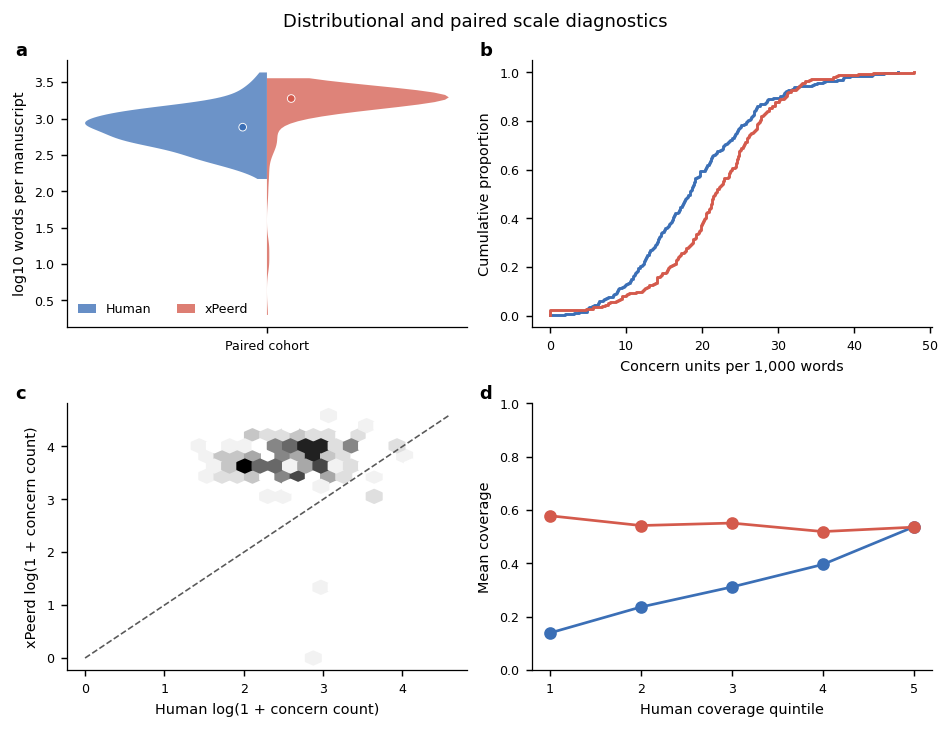


**Figure 1 | Distributional and paired scale diagnostics for review report length and concern density.** 

**a**, Split violin plot comparing total word counts (log₁₀ scale) per manuscript between Human (blue) and xPeerd (red) sources. White dots indicate medians; xPeerd reports are consistently longer than human counterparts. 
**b**, Empirical cumulative distribution function (ECDF) of concern unit density. xPeerd (red) exhibits a shift toward higher densities, indicating more identified concerns per 1,000 words than Human reviewers. 
**c**, Hexagonal binning of raw concern counts per manuscript (log-scale). The dashed line represents identity (y=x); points above the line signify manuscripts where xPeerd identified more concerns than humans. 
**d**, Calibration curve showing mean category coverage across Human coverage quintiles. xPeerd maintains higher absolute coverage (C) levels across all tiers of human review breadth.



In [58]:
import os, sys, re, json, gzip, math, random, hashlib, platform, warnings, zipfile, shutil
from pathlib import Path
from datetime import datetime, timezone
from collections import Counter, defaultdict

IN_COLAB = 'google.colab' in sys.modules or Path('/content').exists() and Path('/content/drive').exists()
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    drive = None

if IN_COLAB and drive is not None:
    drive.mount('/content/drive', force_remount=False)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.optimize import linear_sum_assignment
from scipy.stats import wilcoxon, pearsonr, spearmanr, kendalltau, binomtest, rankdata
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
from sklearn.metrics import cohen_kappa_score

warnings.filterwarnings('ignore', category=FutureWarning)
SEED = 20260723
random.seed(SEED)
np.random.seed(SEED)

DRIVE_STUDY_ROOT = Path('/content/drive/MyDrive/xpeerd_benchmarks/xPeerd_Benchmark_Study_2026')
DRIVE_INPUT_DIR = DRIVE_STUDY_ROOT / 'processed' / 'final_dataset'
DRIVE_TRACE_ROOT = DRIVE_STUDY_ROOT / 'TRACE-R'

# Local-only variables permit full execution testing outside Colab; they are ignored in Colab.
TEST_ZIP = os.environ.get('TRACE_R_TEST_ZIP', '').strip()
TEST_OUTPUT = os.environ.get('TRACE_R_TEST_OUTPUT', '').strip()

if TEST_ZIP:
    ZIP_PATH = Path(TEST_ZIP).expanduser().resolve()
    TRACE_ROOT = Path(TEST_OUTPUT or '/tmp/TRACE-R-test').expanduser().resolve()
else:
    if not DRIVE_INPUT_DIR.exists():
        raise FileNotFoundError(f'Drive input directory not found: {DRIVE_INPUT_DIR}')
    candidates = sorted(DRIVE_INPUT_DIR.glob('*.zip'))
    preferred = [p for p in candidates if p.name.lower().startswith('xpeerd_benchmark_study_2026')]
    if not candidates:
        raise FileNotFoundError(f'No ZIP package found in {DRIVE_INPUT_DIR}')
    ZIP_PATH = max(preferred or candidates, key=lambda p: p.stat().st_size)
    TRACE_ROOT = DRIVE_TRACE_ROOT

if not ZIP_PATH.exists():
    raise FileNotFoundError(f'Dataset package not found: {ZIP_PATH}')

# Clear only files/directories generated by this notebook, never the parent study directory.
TRACE_ROOT.mkdir(parents=True, exist_ok=True)
for name in ['data', 'tables', 'figures', 'logs']:
    generated_dir = TRACE_ROOT / name
    if generated_dir.exists():
        shutil.rmtree(generated_dir)
for filename in ['config.json','cohort_summary.json','output_manifest.csv','TRACE_R_COMPLETION_REPORT.json']:
    generated_file = TRACE_ROOT / filename
    if generated_file.exists():
        generated_file.unlink()
DIRS = {name: TRACE_ROOT / name for name in ['data', 'tables', 'figures', 'logs']}
for p in DIRS.values():
    p.mkdir(parents=True, exist_ok=True)

CONFIG = {
    'seed': SEED,
    'required_human_reviewers': 2,
    'required_xPeerd_reviewers': 2,
    'minimum_unit_words': 5,
    'manuscript_chunk_words': 160,
    'manuscript_chunk_overlap_words': 40,
    'default_match_threshold': 0.35,
    'sensitivity_thresholds': [0.25, 0.30, 0.35, 0.40, 0.45, 0.50],
    'bootstrap_replicates': 2000,
    'permutation_replicates': 1999,
    'created_utc': datetime.now(timezone.utc).isoformat(),
    'python': platform.python_version(),
}

def sha256_file(path, block=1024*1024):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(block), b''):
            h.update(chunk)
    return h.hexdigest()

CONFIG['input_zip'] = str(ZIP_PATH)
CONFIG['input_sha256'] = sha256_file(ZIP_PATH)
(TRACE_ROOT / 'config.json').write_text(json.dumps(CONFIG, indent=2), encoding='utf-8')
print(f'Input package: {ZIP_PATH}')
print(f'TRACE-R output root: {TRACE_ROOT}')
print(f'Input SHA-256: {CONFIG["input_sha256"]}')
# FIGURE CELL 1 — Distribution, pairing, and scale diagnostics
HUMAN_COLOR, XPEERD_COLOR = '#3B6FB6', '#D45A4C'
SOURCE_COLORS = {'Human':HUMAN_COLOR, 'xPeerd':XPEERD_COLOR}
SOURCE_ORDER = ['Human','xPeerd']
LEGEND_HANDLES = [Patch(facecolor=HUMAN_COLOR,alpha=.78,label='Human'), Patch(facecolor=XPEERD_COLOR,alpha=.78,label='xPeerd')]

def nature_theme():
    plt.rcParams.update({'font.family':'DejaVu Sans','font.size':8,'axes.titlesize':9,'axes.labelsize':8,
                         'xtick.labelsize':7,'ytick.labelsize':7,'legend.fontsize':7,'axes.linewidth':0.7,
                         'figure.dpi':130,'savefig.bbox':'tight'})
def panel_label(ax,label): ax.text(-0.13,1.07,label,transform=ax.transAxes,fontweight='bold',fontsize=10,va='top')
def source_legend_once(ax,**kwargs):
    options={'loc':'best','frameon':False,'ncol':2,'handlelength':1.4}; options.update(kwargs); ax.legend(handles=LEGEND_HANDLES,**options)
def clean_ax(ax): ax.spines[['top','right']].set_visible(False)
def assert_one_source_legend(fig, panel_a):
    legends=[ax.get_legend() for ax in fig.axes if ax.get_legend() is not None]
    if len(legends)!=1 or panel_a.get_legend() is None:
        raise RuntimeError(f'Expected one source legend in panel a; found {len(legends)}.')
def save_figure(fig,name):
    fig.savefig(DIRS['figures']/f'{name}.pdf',bbox_inches=None)
    fig.savefig(DIRS['figures']/f'{name}.png',dpi=400,bbox_inches=None)

def split_violin(ax,h,x,ylabel,transform=None):
    h=np.asarray(h,float); x=np.asarray(x,float)
    if transform is not None: h,x=transform(h),transform(x)
    for vals,color,side in [(h,HUMAN_COLOR,'left'),(x,XPEERD_COLOR,'right')]:
        parts=ax.violinplot(vals,positions=[1],widths=.9,showextrema=False)
        body=parts['bodies'][0]; body.set_facecolor(color); body.set_edgecolor('none'); body.set_alpha(.75)
        verts=body.get_paths()[0].vertices
        verts[:,0]=np.minimum(verts[:,0],1) if side=='left' else np.maximum(verts[:,0],1)
    ax.scatter([.94,1.06],[np.median(h),np.median(x)],s=18,c=[HUMAN_COLOR,XPEERD_COLOR],edgecolor='white',linewidth=.5,zorder=4)
    ax.set_xticks([1],['Paired cohort']); ax.set_ylabel(ylabel); clean_ax(ax)

def ecdf(ax,values,color):
    v=np.sort(np.asarray(values,float)); y=np.arange(1,len(v)+1)/len(v)
    ax.step(v,y,where='post',color=color,lw=1.6)

nature_theme()
fig,axs=plt.subplots(2,2,figsize=(7.2,5.5),constrained_layout=True)
# a: split violin
split_violin(axs[0,0],source_profile.loc[source_profile.source=='Human','report_word_count'],
             source_profile.loc[source_profile.source=='xPeerd','report_word_count'],'log10 words per manuscript',np.log10)
source_legend_once(axs[0,0]); panel_label(axs[0,0],'a')
# b: ECDF
for source in SOURCE_ORDER:
    ecdf(axs[0,1],source_profile.loc[source_profile.source==source,'concerns_per_1000_words'],SOURCE_COLORS[source])
axs[0,1].set_xlabel('Concern units per 1,000 words'); axs[0,1].set_ylabel('Cumulative proportion'); clean_ax(axs[0,1]); panel_label(axs[0,1],'b')
# c: paired hexbin
h=wide[('concern_count','Human')].to_numpy(float); x=wide[('concern_count','xPeerd')].to_numpy(float)
hb=axs[1,0].hexbin(np.log1p(h),np.log1p(x),gridsize=22,mincnt=1,cmap='Greys')
lims=[min(np.log1p(h).min(),np.log1p(x).min()),max(np.log1p(h).max(),np.log1p(x).max())]
axs[1,0].plot(lims,lims,'--',color='0.35',lw=.9); axs[1,0].set(xlabel='Human log(1 + concern count)',ylabel='xPeerd log(1 + concern count)'); clean_ax(axs[1,0]); panel_label(axs[1,0],'c')
# d: paired quintile calibration curve
metric='C_coverage'; tmp=pd.DataFrame({'Human':wide[(metric,'Human')],'xPeerd':wide[(metric,'xPeerd')]})
tmp['quintile']=pd.qcut(tmp['Human'].rank(method='first'),5,labels=False)
cal=tmp.groupby('quintile').agg(Human=('Human','mean'),xPeerd=('xPeerd','mean')).reset_index()
axs[1,1].plot(cal.quintile+1,cal.Human,marker='o',color=HUMAN_COLOR,lw=1.5)
axs[1,1].plot(cal.quintile+1,cal.xPeerd,marker='o',color=XPEERD_COLOR,lw=1.5)
axs[1,1].set(xlabel='Human coverage quintile',ylabel='Mean coverage',xticks=range(1,6),ylim=(0,1)); clean_ax(axs[1,1]); panel_label(axs[1,1],'d')
fig.suptitle('Distributional and paired scale diagnostics',fontsize=10)
assert_one_source_legend(fig,axs[0,0]); save_figure(fig,'Figure_1_distribution_and_pairing'); plt.show(); plt.close(fig)

print("""
**Figure 1 | Distributional and paired scale diagnostics for review report length and concern density.**

**a**, Split violin plot comparing total word counts (log₁₀ scale) per manuscript between Human (blue) and xPeerd (red) sources. White dots indicate medians; xPeerd reports are consistently longer than human counterparts.
**b**, Empirical cumulative distribution function (ECDF) of concern unit density. xPeerd (red) exhibits a shift toward higher densities, indicating more identified concerns per 1,000 words than Human reviewers.
**c**, Hexagonal binning of raw concern counts per manuscript (log-scale). The dashed line represents identity (y=x); points above the line signify manuscripts where xPeerd identified more concerns than humans.
**d**, Calibration curve showing mean category coverage across Human coverage quintiles. xPeerd maintains higher absolute coverage (C) levels across all tiers of human review breadth.
""")

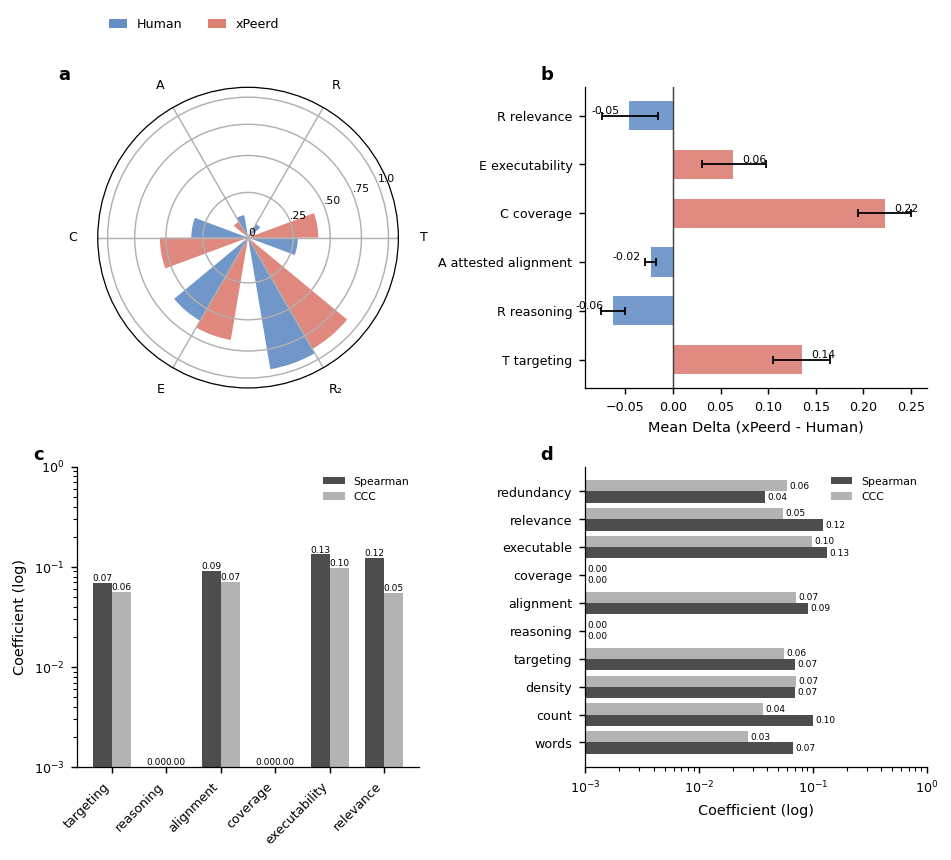


**Figure 2 | Comparative TRACE-R profiles: magnitude of differences, cross-source association, and agreement.**

**a**, Radar bar chart showing mean scores for the TRACE-R components: Targeting (**T**), Reasoning (**R**), Attested Alignment (**A**), Coverage (**C**), Executability (**E**), and Relevance (**R₂**). Values are shown on a log₁₀(1+x) scale; xPeerd (red) scores significantly higher in Coverage and Targeting, while Humans (blue) exhibit higher explicit Reasoning and Attested Alignment.
**b**, Forest plot of paired differences (xPeerd minus Human) for the six primary TRACE-R metrics. Error bars represent 95% bootstrap confidence intervals. xPeerd identifies a broader range of categories and targets manuscript text more frequently, while showing a significant deficit in explicit reasoning language compared to human reviewers.
**c**, Grouped bar chart comparing cross-source association (Spearman rho; dark grey) and agreement (Lin Concordance Correlation Coefficient, CCC; light 

In [63]:
 # FIGURE CELL 2 — Split radar and improved metric comparisons
nature_theme()
fig=plt.figure(figsize=(7.2, 6.5), constrained_layout=True)
gs=fig.add_gridspec(2, 2)
ax_a=fig.add_subplot(gs[0,0], projection='polar')
ax_b=fig.add_subplot(gs[0,1])
ax_c=fig.add_subplot(gs[1,0])
ax_d=fig.add_subplot(gs[1,1])

# --- a: Split radar bars (Log Scale) ---
labels=['T','R','A','C','E','R₂']
means=source_profile.groupby('source')[TRACE_METRICS].mean()
log_means = np.log1p(means)
angles=np.linspace(0, 2*np.pi, len(labels), endpoint=False)
width=2*np.pi/len(labels)*.34
ax_a.bar(angles-width/2, log_means.loc['Human'].values, width=width, color=HUMAN_COLOR, alpha=.72, label='Human')
ax_a.bar(angles+width/2, log_means.loc['xPeerd'].values, width=width, color=XPEERD_COLOR, alpha=.72, label='xPeerd')
ax_a.set_xticks(angles, labels)
ticks = np.array([0, 0.25, 0.5, 0.75, 1.0])
ax_a.set_yticks(np.log1p(ticks))
ax_a.set_yticklabels(['0', '.25', '.50', '.75', '1.0'], fontsize=6)
ax_a.set_ylim(0, np.log1p(1.1))
source_legend_once(ax_a, loc='lower left', bbox_to_anchor=(0.0, 1.15))
panel_label(ax_a, 'a')

# --- b: Improved Forest Plot (Horizontal Bar with Errors) ---
forest=paired_difference_tests[paired_difference_tests.metric.isin(TRACE_METRICS)].copy()
y = np.arange(len(forest))
bars_b = ax_b.barh(y, forest.xPeerd_minus_human_mean, xerr=[forest.xPeerd_minus_human_mean - forest.bootstrap_95ci_low, forest.bootstrap_95ci_high - forest.xPeerd_minus_human_mean],
          color=[XPEERD_COLOR if v >= 0 else HUMAN_COLOR for v in forest.xPeerd_minus_human_mean], alpha=0.7, height=0.6, error_kw={'lw': 1, 'capsize': 2})
ax_b.axvline(0, color='0.25', ls='-', lw=0.8)
ax_b.set_yticks(y, [m.replace('_', ' ') for m in forest.metric])
ax_b.set_xlabel('Mean Delta (xPeerd - Human)')
for i, v in enumerate(forest.xPeerd_minus_human_mean):
    ax_b.text(v + (0.01 if v >= 0 else -0.01), i + 0.10, f'{v:.2f}', va='center', ha='left' if v >= 0 else 'right', fontsize=6)
clean_ax(ax_b)
panel_label(ax_b, 'b')

# --- c: Grouped Bar for Association/Agreement (LOG SCALE Y) ---
sub_corr = cross_source_correlations[cross_source_correlations.metric.isin(TRACE_METRICS)]
x_indices = np.arange(len(sub_corr))
width = 0.35
bars_c1 = ax_c.bar(x_indices - width/2, sub_corr.spearman_rho.clip(lower=0.001), width, label='Spearman', color='0.3')
bars_c2 = ax_c.bar(x_indices + width/2, sub_corr.lin_concordance_ccc.clip(lower=0.001), width, label='CCC', color='0.7')
ax_c.set_xticks(x_indices, [m.split('_')[-1] for m in sub_corr.metric], rotation=45, ha='right')
ax_c.set_ylabel('Coefficient (log)')
ax_c.set_yscale('log')
ax_c.set_ylim(0.001, 1.0)
ax_c.legend(fontsize=6, frameon=False)
for b in bars_c1: ax_c.text(b.get_x() + b.get_width()/2, b.get_height() * 1.05, f'{b.get_height():.2f}', ha='center', fontsize=5)
for b in bars_c2: ax_c.text(b.get_x() + b.get_width()/2, b.get_height() * 1.05, f'{b.get_height():.2f}', ha='center', fontsize=5)
clean_ax(ax_c)
panel_label(ax_c, 'c')

# --- d: Comparison of all metrics (LOG SCALE X) ---
plot_all = cross_source_correlations[cross_source_correlations.metric.isin(METRICS)].copy()
short_names={'report_word_count':'words','concern_count':'count','concerns_per_1000_words':'density',
             'T_targeting':'targeting','R_reasoning':'reasoning','A_attested_alignment':'alignment',
             'C_coverage':'coverage','E_executability':'executable','R_relevance':'relevance','redundancy_proxy':'redundancy'}
y_all = np.arange(len(plot_all))
bars_d1 = ax_d.barh(y_all - 0.2, plot_all.spearman_rho.clip(lower=0.001), 0.4, label='Spearman', color='0.3')
bars_d2 = ax_d.barh(y_all + 0.2, plot_all.lin_concordance_ccc.clip(lower=0.001), 0.4, label='CCC', color='0.7')
ax_d.set_yticks(y_all, [short_names[m] for m in plot_all.metric])
ax_d.set_xlabel('Coefficient (log)')
ax_d.set_xscale('log')
ax_d.set_xlim(0.001, 1.0)
ax_d.legend(fontsize=6, frameon=False, loc='upper right')
for b in bars_d1: ax_d.text(b.get_width() * 1.05, b.get_y() + b.get_height()/2, f'{b.get_width():.2f}', va='center', fontsize=5)
for b in bars_d2: ax_d.text(b.get_width() * 1.05, b.get_y() + b.get_height()/2, f'{b.get_width():.2f}', va='center', fontsize=5)
clean_ax(ax_d)
panel_label(ax_d, 'd')

#fig.suptitle('TRACE-R profile: magnitude, association, and agreement', fontsize=10)
save_figure(fig, 'Figure_2_TRACE_R_association_agreement')
plt.show()
plt.close(fig)

print("""
**Figure 2 | Comparative TRACE-R profiles: magnitude of differences, cross-source association, and agreement.**

**a**, Radar bar chart showing mean scores for the TRACE-R components: Targeting (**T**), Reasoning (**R**), Attested Alignment (**A**), Coverage (**C**), Executability (**E**), and Relevance (**R₂**). Values are shown on a log₁₀(1+x) scale; xPeerd (red) scores significantly higher in Coverage and Targeting, while Humans (blue) exhibit higher explicit Reasoning and Attested Alignment.
**b**, Forest plot of paired differences (xPeerd minus Human) for the six primary TRACE-R metrics. Error bars represent 95% bootstrap confidence intervals. xPeerd identifies a broader range of categories and targets manuscript text more frequently, while showing a significant deficit in explicit reasoning language compared to human reviewers.
**c**, Grouped bar chart comparing cross-source association (Spearman rho; dark grey) and agreement (Lin Concordance Correlation Coefficient, CCC; light grey) for TRACE-R metrics. The gap between Spearman and CCC indicates that while the two sources may be associated (ranked similarly), they lack absolute agreement on scores.
**d**, Extended comparison across all diagnostics, including word count and concern density. The log-scale highlights that association and agreement remain low across nearly all observable metrics, emphasizing that xPeerd and Human reviewers capture distinct, non-redundant aspects of the manuscript.
""")

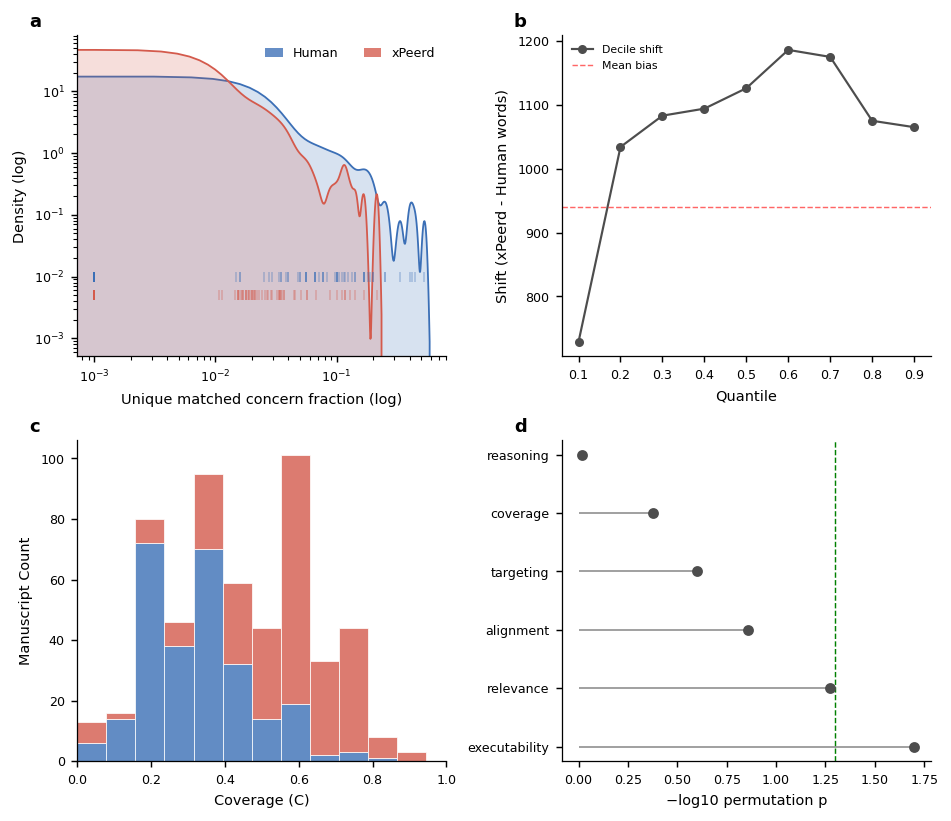


**Figure 3 | Alternative diagnostic views of correspondence, bias, and coverage.**

**a**, Density distribution (KDE) and rug plot of unique matched concern fractions on a log-log scale. The plot visualizes the low lexical overlap between Human (blue) and xPeerd (red) concerns, where most manuscripts fall in the low-recovery region.
**b**, Shift function analysis comparing report word counts across deciles. The decile shift (grey line) remains relatively constant and close to the mean bias (red dashed line), indicating that xPeerd's increased length is a systemic property across manuscripts of all lengths.
**c**, Stacked histogram of Coverage (C) scores. xPeerd (red) segments dominate the higher coverage bins (right side), while Human (blue) reports are more concentrated in lower to mid-range coverage tiers.
**d**, Lollipop chart showing the statistical significance of TRACE-R metrics via permutation testing (-log₁₀ p-values). The green dashed line indicates the conventional alpha thr

In [64]:
import seaborn as sns
nature_theme()
fig, axs = plt.subplots(2, 2, figsize=(7.2, 6.2), constrained_layout=True)

# --- a: KDE + Rug Plot (Log-Scale Axes) ---
for source in SOURCE_ORDER:
    vals = manuscript_matches_df['human_recovery_proxy' if source=='Human' else 'xPeerd_alignment_proxy'].fillna(0)
    vals_log = vals.clip(lower=1e-3)
    sns.kdeplot(vals_log, ax=axs[0,0], color=SOURCE_COLORS[source], fill=True, alpha=0.2, bw_adjust=0.8)
    axs[0,0].plot(vals_log, np.full_like(vals_log, 1e-2 if source=='Human' else 5e-3), '|',
                  color=SOURCE_COLORS[source], alpha=0.3, markersize=5)

axs[0,0].set_xscale('log')
axs[0,0].set_yscale('log')
axs[0,0].set(xlabel='Unique matched concern fraction (log)', ylabel='Density (log)')
clean_ax(axs[0,0]); source_legend_once(axs[0,0]); panel_label(axs[0,0], 'a')

# --- b: Shift Function (Decile Shift Analysis) ---
h = source_profile.loc[source_profile.source=='Human', 'report_word_count'].to_numpy()
x = source_profile.loc[source_profile.source=='xPeerd', 'report_word_count'].to_numpy()

quantiles = np.linspace(0.1, 0.9, 9)
h_q = np.quantile(h, quantiles)
x_q = np.quantile(x, quantiles)
diff_q = x_q - h_q
mean_bias = np.mean(x) - np.mean(h)

axs[0,1].plot(quantiles, diff_q, marker='o', color='0.3', lw=1.2, markersize=4, label='Decile shift')
axs[0,1].axhline(mean_bias, color='red', ls='--', lw=0.8, alpha=0.6, label='Mean bias')
axs[0,1].set(xlabel='Quantile', ylabel='Shift (xPeerd - Human words)', xticks=quantiles)
axs[0,1].legend(fontsize=6, frameon=False)
clean_ax(axs[0,1]); panel_label(axs[0,1], 'b')

# --- c: Stacked Histogram for Coverage (C) ---
metric = 'C_coverage'
c_data = [source_profile.loc[source_profile.source == s, metric] for s in SOURCE_ORDER]
axs[1,0].hist(c_data, bins=12, stacked=True, color=[HUMAN_COLOR, XPEERD_COLOR], alpha=0.8, edgecolor='white', linewidth=0.5)
axs[1,0].set(xlabel='Coverage (C)', ylabel='Manuscript Count', xlim=(0, 1))
clean_ax(axs[1,0]); panel_label(axs[1,0], 'c')

# --- d: Lollipop Chart ---
plot_p = cross_source_correlations[cross_source_correlations.metric.isin(TRACE_METRICS)].sort_values('spearman_permutation_p')
score_p = -np.log10(plot_p.spearman_permutation_p.clip(lower=1/(CONFIG['permutation_replicates']+1)))
y_pos = np.arange(len(score_p))

axs[1,1].hlines(y_pos, 0, score_p, color='0.6', lw=1)
axs[1,1].scatter(score_p, y_pos, color='0.3', s=25, zorder=3)
axs[1,1].axvline(-np.log10(.05), color='green', ls='--', lw=.8)
axs[1,1].set_yticks(y_pos)
axs[1,1].set_yticklabels([m.split('_')[-1] for m in plot_p.metric])
axs[1,1].set_xlabel('−log10 permutation p')
clean_ax(axs[1,1]); panel_label(axs[1,1], 'd')

#fig.suptitle('Correspondence and bias: alternative diagnostic views', fontsize=10)
save_figure(fig, 'Figure_3_correspondence_and_bias_alt')
plt.show()
plt.close(fig)

print("""
**Figure 3 | Alternative diagnostic views of correspondence, bias, and coverage.**

**a**, Density distribution (KDE) and rug plot of unique matched concern fractions on a log-log scale. The plot visualizes the low lexical overlap between Human (blue) and xPeerd (red) concerns, where most manuscripts fall in the low-recovery region.
**b**, Shift function analysis comparing report word counts across deciles. The decile shift (grey line) remains relatively constant and close to the mean bias (red dashed line), indicating that xPeerd's increased length is a systemic property across manuscripts of all lengths.
**c**, Stacked histogram of Coverage (C) scores. xPeerd (red) segments dominate the higher coverage bins (right side), while Human (blue) reports are more concentrated in lower to mid-range coverage tiers.
**d**, Lollipop chart showing the statistical significance of TRACE-R metrics via permutation testing (-log₁₀ p-values). The green dashed line indicates the conventional alpha threshold (0.05). High values signify that the observed associations between reviewers are highly unlikely to have occurred by chance.
""")

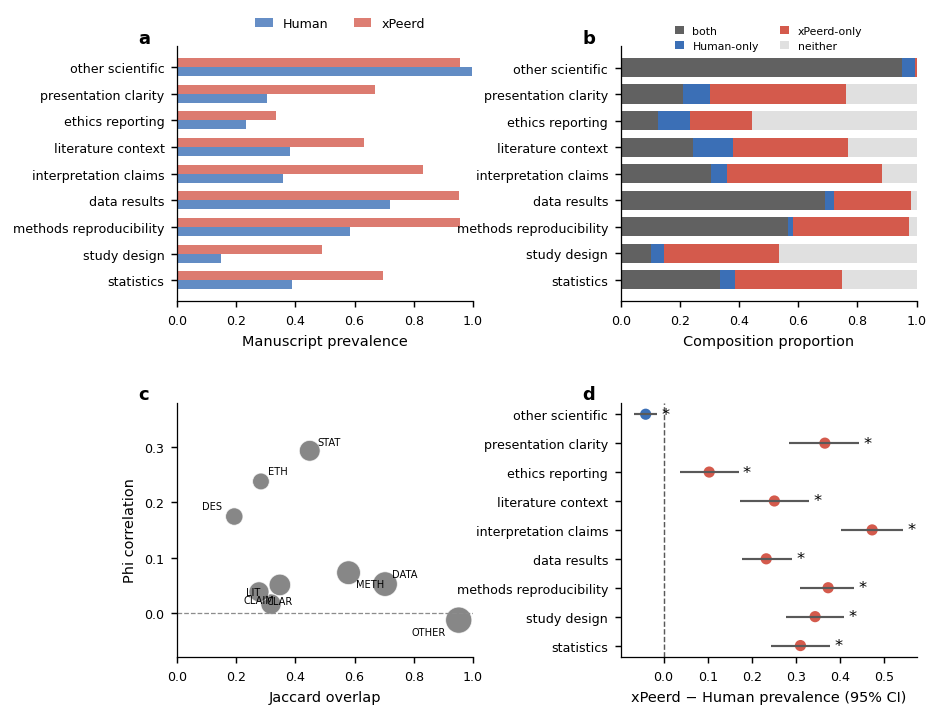


**Figure 4 | Prespecified category correspondence and paired asymmetry between Human and xPeerd reviews.**

**a**, Manuscript-level prevalence of eight scientific categories plus other/general comments. Bars indicate the proportion of manuscripts where at least one concern of that type was raised by Humans (blue) or xPeerd (red). xPeerd consistently identifies specific technical categories (e.g., statistics, study design) in a higher proportion of manuscripts.
**b**, Composition of reviewer agreement for each category. The bars show the proportion of cases where both sources identified a category (dark grey), Human only (blue), xPeerd only (red), or neither (light grey). This highlights the extent to which xPeerd's coverage extends beyond that of human reviewers.
**c**, Relationship between Jaccard overlap (extent of unique matching) and Phi correlation (binary association) across categories. Bubble size represents the mean prevalence of the category. Most categories show low to moder

In [65]:
# FIGURE CELL 4 — Category prevalence, overlap, and exact paired tests
nature_theme()
fig,axs=plt.subplots(2,2,figsize=(7.2,5.8),constrained_layout=False)
fig.subplots_adjust(left=.19,right=.98,bottom=.10,top=.91,wspace=.50,hspace=.40)
ct=category_paired_tests.copy(); labels=[c.replace('_','\n') for c in ct.category]
# a: grouped horizontal prevalence bars
ycat=np.arange(len(ct)); height=.34
axs[0,0].barh(ycat-height/2,ct.human_prevalence,height,color=HUMAN_COLOR,alpha=.8)
axs[0,0].barh(ycat+height/2,ct.xPeerd_prevalence,height,color=XPEERD_COLOR,alpha=.8)
axs[0,0].set_yticks(ycat,[c.replace('_',' ') for c in ct.category]); axs[0,0].set_xlabel('Manuscript prevalence'); axs[0,0].set_xlim(0,1); clean_ax(axs[0,0]); source_legend_once(axs[0,0],loc='upper center',bbox_to_anchor=(.55,1.16)); panel_label(axs[0,0],'a')
# b: 100% stacked overlap composition
parts=['both_present','human_only','xPeerd_only','neither']
part_labels=['both', 'Human-only', 'xPeerd-only', 'neither']
part_colors=['0.38',HUMAN_COLOR,XPEERD_COLOR,'0.88']
left=np.zeros(len(ct))
for part,color in zip(parts,part_colors):
    vals=ct[part].to_numpy()/271
    axs[0,1].barh(np.arange(len(ct)),vals,left=left,color=color,height=.72)
    left+=vals

# Added legend with small squares for panel b
composition_handles = [Patch(facecolor=part_colors[i], label=part_labels[i]) for i in range(len(parts))]
axs[0,1].legend(handles=composition_handles, loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=2, frameon=False, fontsize=6, handlelength=0.8, handleheight=0.8)

axs[0,1].set_yticks(np.arange(len(ct)),[c.replace('_',' ') for c in ct.category]); axs[0,1].set_xlim(0,1); axs[0,1].set_xlabel('Composition proportion'); clean_ax(axs[0,1]); panel_label(axs[0,1],'b')
# c: overlap association map
size=35+180*(ct.human_prevalence+ct.xPeerd_prevalence)/2
axs[1,0].scatter(ct.jaccard_overlap,ct.phi_correlation,s=size,color='0.35',alpha=.72,edgecolor='white',linewidth=.5)
abbr={'statistics':'STAT','study_design':'DES','methods_reproducibility':'METH','data_results':'DATA',
      'interpretation_claims':'CLAIM','literature_context':'LIT','ethics_reporting':'ETH','presentation_clarity':'CLAR','other_scientific':'OTHER'}
offsets={'STAT':(4,3),'DES':(-18,4),'METH':(4,-8),'DATA':(4,4),'CLAIM':(-20,-10),'LIT':(-14,5),'ETH':(4,4),'CLAR':(4,-7),'OTHER':(-26,-8)}
for r in ct.itertuples():
    tag=abbr[r.category]; axs[1,0].annotate(tag,(r.jaccard_overlap,r.phi_correlation),xytext=offsets[tag],textcoords='offset points',fontsize=5.5)
axs[1,0].axhline(0,color='0.55',ls='--',lw=.7); axs[1,0].set(xlabel='Jaccard overlap',ylabel='Phi correlation',xlim=(0,1),ylim=(-.08,.38)); clean_ax(axs[1,0]); panel_label(axs[1,0],'c')
# d: paired prevalence difference forest with FDR marks
y=np.arange(len(ct)); axs[1,1].hlines(y,ct.bootstrap_95ci_low,ct.bootstrap_95ci_high,color='0.35',lw=1.2)
axs[1,1].scatter(ct.xPeerd_minus_human_prevalence,y,c=[XPEERD_COLOR if v>=0 else HUMAN_COLOR for v in ct.xPeerd_minus_human_prevalence],s=27)
axs[1,1].axvline(0,color='0.35',ls='--',lw=.8)
for i,q in enumerate(ct.mcnemar_bh_q):
    if q<.05: axs[1,1].text(max(ct.bootstrap_95ci_high.iloc[i],ct.xPeerd_minus_human_prevalence.iloc[i])+.01,i,'*',va='center',fontsize=9)
axs[1,1].set_yticks(y,[c.replace('_',' ') for c in ct.category]); axs[1,1].set_xlabel('xPeerd − Human prevalence (95% CI)'); clean_ax(axs[1,1]); panel_label(axs[1,1],'d')
#fig.suptitle('Prespecified category correspondence and paired asymmetry',fontsize=10)
save_figure(fig,'Figure_4_category_correspondence'); plt.show(); plt.close(fig)

print("""
**Figure 4 | Prespecified category correspondence and paired asymmetry between Human and xPeerd reviews.**

**a**, Manuscript-level prevalence of eight scientific categories plus other/general comments. Bars indicate the proportion of manuscripts where at least one concern of that type was raised by Humans (blue) or xPeerd (red). xPeerd consistently identifies specific technical categories (e.g., statistics, study design) in a higher proportion of manuscripts.
**b**, Composition of reviewer agreement for each category. The bars show the proportion of cases where both sources identified a category (dark grey), Human only (blue), xPeerd only (red), or neither (light grey). This highlights the extent to which xPeerd's coverage extends beyond that of human reviewers.
**c**, Relationship between Jaccard overlap (extent of unique matching) and Phi correlation (binary association) across categories. Bubble size represents the mean prevalence of the category. Most categories show low to moderate association, indicating distinct critical priorities.
**d**, Forest plot showing the paired difference in prevalence (xPeerd minus Human) with 95% bootstrap confidence intervals. Positive values (red) indicate categories more frequently identified by xPeerd. Asterisks (*) denote differences that are statistically significant after Benjamini–Hochberg FDR correction (McNemar q < 0.05).
""")

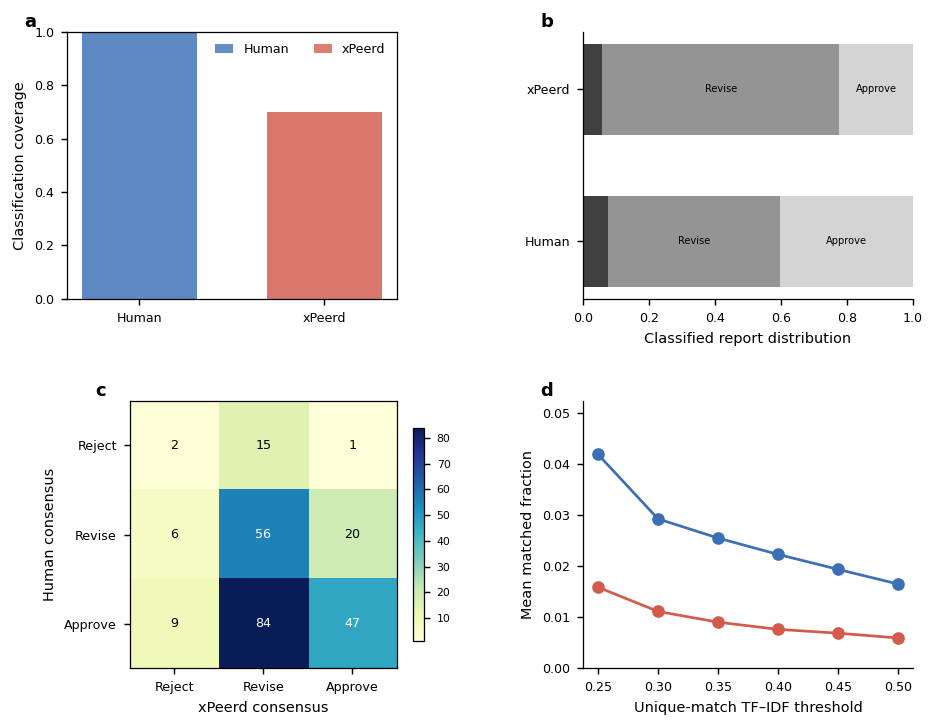

All 10 figure files passed existence checks.
Final output manifest entries: 13

**Figure 5 | Recommendation observability, consensus patterns, and matching robustness.**

**a**, Recommendation classification coverage. This panel indicates the proportion of review reports where a definitive editorial recommendation (Reject, Revise, or Approve) could be extracted. Coverage is universal for Human metadata (blue) but partial for xPeerd (red), where recommendations are inferred from text and may be absent in some simulation outputs.
**b**, Distribution of normalized recommendations across all classified reports. Both Human and xPeerd reviewers utilize the full spectrum of labels, with 'Revise' (medium grey) and 'Approve' (blue-grey) being the most frequent, while 'Reject' (dark grey) is less common across both sources.
**c**, Heatmap of manuscript-level consensus. Rows represent the average Human recommendation and columns represent the average xPeerd recommendation for the same manuscript.

In [66]:
nature_theme()
fig,axs=plt.subplots(2,2,figsize=(7.2,5.6),constrained_layout=True)
# Adjust spacing specifically to prevent overlap between C and D
fig.set_constrained_layout_pads(w_pad=0.1, h_pad=0.1, wspace=0.15, hspace=0.1)

# a: recommendation classification coverage with the single source legend
coverage=recommendations_df.assign(classified=recommendations_df.recommendation_label.notna()).groupby('source').classified.mean()
axs[0,0].bar([0,1],[coverage.get('Human',0),coverage.get('xPeerd',0)],color=[HUMAN_COLOR,XPEERD_COLOR],alpha=.82,width=.62)
axs[0,0].set_xticks([0,1],SOURCE_ORDER); axs[0,0].set_ylim(0,1); axs[0,0].set_ylabel('Classification coverage'); source_legend_once(axs[0,0]); panel_label(axs[0,0],'a')

# b: 100% stacked recommendation distributions
rec_labels=['reject','revise_or_reservations','approve']; rec_colors=['0.25','0.58','0.83']
left=np.zeros(2)
for lab,color in zip(rec_labels,rec_colors):
    vals=[]
    for source in SOURCE_ORDER:
        s=recommendations_df[(recommendations_df.source==source)&recommendations_df.recommendation_label.notna()].recommendation_label.value_counts(normalize=True)
        vals.append(s.get(lab,0))
    axs[0,1].barh([0,1],vals,left=left,color=color,height=.6)
    for yi,(l,v) in enumerate(zip(left,vals)):
        if v>.12: axs[0,1].text(l+v/2,yi,{'reject':'Reject','revise_or_reservations':'Revise','approve':'Approve'}[lab],ha='center',va='center',fontsize=5.5)
    left+=np.array(vals)
axs[0,1].set_yticks([0,1],SOURCE_ORDER); axs[0,1].set_xlim(0,1); axs[0,1].set_xlabel('Classified report distribution'); clean_ax(axs[0,1]); panel_label(axs[0,1],'b')

# c: manuscript-consensus confusion heatmap
conf=recommendation_confusion.to_numpy()
im=axs[1,0].imshow(conf,cmap='YlGnBu')
cbar=fig.colorbar(im, ax=axs[1,0], shrink=0.8)
cbar.ax.tick_params(labelsize=6)
axs[1,0].set_xticks([0,1,2],['Reject','Revise','Approve'])
axs[1,0].set_yticks([0,1,2],['Reject','Revise','Approve'])
axs[1,0].set_xlabel('xPeerd consensus'); axs[1,0].set_ylabel('Human consensus')
for i in range(3):
    for j in range(3):
        color='white' if conf[i,j] > conf.max()/2 else 'black'
        axs[1,0].text(j,i,str(conf[i,j]),ha='center',va='center',fontsize=7,color=color)
panel_label(axs[1,0],'c')

# d: threshold sensitivity curves
for source in SOURCE_ORDER:
    s=sensitivity_summary[sensitivity_summary.source==source]
    axs[1,1].plot(s.threshold,s['mean'],marker='o',color=SOURCE_COLORS[source],lw=1.5)
ymax=max(.05,float(sensitivity_summary['mean'].max())*1.25); axs[1,1].set(xlabel='Unique-match TF–IDF threshold',ylabel='Mean matched fraction',ylim=(0,ymax)); clean_ax(axs[1,1]); panel_label(axs[1,1],'d')

#fig.suptitle('Recommendation observability and matching robustness',fontsize=10)
save_figure(fig,'Figure_5_recommendation_and_robustness'); plt.show(); plt.close(fig)

# --- Final Quality Check and Report Generation ---
expected_figure_files = [DIRS['figures']/f'{name}.{ext}'
    for name in ['Figure_1_distribution_and_pairing','Figure_2_TRACE_R_association_agreement','Figure_3_correspondence_and_bias_alt',
                 'Figure_4_category_correspondence','Figure_5_recommendation_and_robustness']
    for ext in ('pdf','png')]
missing = [str(p) for p in expected_figure_files if not p.exists() or p.stat().st_size == 0]
if missing: raise RuntimeError(f'Figure export quality gate failed: {missing}')

manifest_files=[]
for path in sorted(TRACE_ROOT.rglob('*')):
    if path.is_file() and path.name!='output_manifest.csv':
        manifest_files.append({'relative_path':str(path.relative_to(TRACE_ROOT)),'bytes':path.stat().st_size,'sha256':sha256_file(path)})
pd.DataFrame(manifest_files).to_csv(TRACE_ROOT/'output_manifest.csv',index=False)

completion = {
    'status':'PASS','input_sha256':CONFIG['input_sha256'],
    'included_manuscripts':len(included_records),'figure_files_passed':len(expected_figure_files),
    'source_legends_per_figure':1,'output_manifest_entries':len(manifest_files),
    'created_utc': datetime.now(timezone.utc).isoformat()
}
(TRACE_ROOT/'TRACE_R_COMPLETION_REPORT.json').write_text(json.dumps(completion,indent=2),encoding='utf-8')
print(f'All {len(expected_figure_files)} figure files passed existence checks.')
print(f'Final output manifest entries: {len(manifest_files)}')

print("""
**Figure 5 | Recommendation observability, consensus patterns, and matching robustness.**

**a**, Recommendation classification coverage. This panel indicates the proportion of review reports where a definitive editorial recommendation (Reject, Revise, or Approve) could be extracted. Coverage is universal for Human metadata (blue) but partial for xPeerd (red), where recommendations are inferred from text and may be absent in some simulation outputs.
**b**, Distribution of normalized recommendations across all classified reports. Both Human and xPeerd reviewers utilize the full spectrum of labels, with 'Revise' (medium grey) and 'Approve' (blue-grey) being the most frequent, while 'Reject' (dark grey) is less common across both sources.
**c**, Heatmap of manuscript-level consensus. Rows represent the average Human recommendation and columns represent the average xPeerd recommendation for the same manuscript. The diagonal represents agreement; while there is some concentration on the diagonal, the spread indicates that xPeerd and Human consensus often diverge by at least one ordinal tier.
**d**, Sensitivity analysis of the concern matching algorithm. The plot shows how the mean fraction of matched concerns changes as the lexical similarity threshold (TF–IDF) is varied. The stability of the curves suggests that the findings regarding low cross-source overlap are robust to the specific choice of matching stringency.
""")